# METAR Data

**Author**: Phillipe Lothaller  
**Date**: 30/04/2026

---

METAR (Meteorological Aerodrome Report) data consists of standardised weather observation reports produced at aerodromes at regular intervals. Each report captures current weather conditions and phenomena at a given location, including parameters such as wind, visibility, cloud cover, and temperature.

We source METAR data from two providers. The first is the KLM SQL database, which offers straightforward access but is generally limited to two readings per hour per airport. The second is the IOWA Environmental Mesonet (https://mesonet.agron.iastate.edu/request/download.phtml), a database that stores more granular METAR observations. This notebook investigates the quality and temporal resolution of weather data available through the IOWA Environmental Mesonet, with the aim of determining its suitability for higher-frequency analysis.


In [1]:
import logging
import polars as pl
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# load plot styles
# # plot style (contml unavailable)
# # set_plot_style()  # contml unavailable

# clear existing logging handlers (prevents duplicate logs in notebooks)
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# configure logging
logging.basicConfig(
    level=logging.INFO,  
    format='%(asctime)s - %(levelname)s - %(message)s'
)

## Extract KLM SQL METAR Data

In [2]:
from pathlib import Path
import pandas as pd
import sys
from datetime import date

# Resolve project root
_here = Path.cwd()
_root = _here
for _ in range(6):
    if (_root / "pyproject.toml").exists():
        break
    _root = _root.parent

PROCESSED_DATA_PATH = _root / "data" / "processed"
SQL_PATH = _root / "sql"

# Load cleaned flight data (filtered and cleaned in exploration.ipynb)
cleaned_pd = pd.read_parquet(PROCESSED_DATA_PATH / "klm_cleaned_data_2023_2026(0).parquet")
cleaned_df = pl.from_pandas(cleaned_pd)

logging.info(f"Loaded cleaned flight data: {cleaned_df.height} rows, {len(cleaned_df.columns)} columns")
logging.info(f"Full date range in cleaned data: {cleaned_df['fl_scheduled_departure_date_utc'].min()} to {cleaned_df['fl_scheduled_departure_date_utc'].max()}")

# ── Date range for extraction ──────────────────────────────────────────────────
# Set these to match the range used in run_weather_extraction.py.
# Set to None to use the full cleaned data range.
START_DATE: str | None = "2025-01-01"
END_DATE:   str | None = "2025-12-31"

if START_DATE is None:
    START_DATE = str(cleaned_df["fl_scheduled_departure_date_utc"].min())[:10]
if END_DATE is None:
    END_DATE = str(cleaned_df["fl_scheduled_departure_date_utc"].max())[:10]

logging.info(f"Using extraction date range: {START_DATE} to {END_DATE}")

# Filter cleaned_df to the same date range so IEM extraction is consistent
# Cast string dates to pl.Date for comparison with the date column
cleaned_df_filtered = cleaned_df.filter(
    (pl.col("fl_scheduled_departure_date_utc") >= pl.lit(date.fromisoformat(START_DATE)))
    & (pl.col("fl_scheduled_departure_date_utc") <= pl.lit(date.fromisoformat(END_DATE)))
)
logging.info(f"Filtered cleaned data for date range: {cleaned_df_filtered.height} rows")

# Rename key columns to match METAR SQL output convention
flight_details_df = cleaned_df_filtered.select([
    pl.col("flight_leg_key").alias("flight_key_id"),
    pl.col("fl_actual_in_block_time_utc").alias("fl_actual_arrival_time_utc"),
    pl.col("fl_arrival_airport_icao_code").alias("lkpa_arrival_airport_icao_code"),
    pl.col("fl_actual_arrival_airport").alias("fl_arrival_airport"),
]).filter(
    pl.col("fl_actual_arrival_time_utc").is_not_null()
    & pl.col("lkpa_arrival_airport_icao_code").is_not_null()
)

logging.info(f"flight_details_df ready for METAR matching: {flight_details_df.height} rows")

# Load the METAR SQL query
metar_sql_path = SQL_PATH / "extract_metar_data.sql"
klm_metar_query = metar_sql_path.read_text()
logging.info(f"Loaded METAR SQL query from {metar_sql_path}")

2026-05-15 12:05:09,583 - INFO - Loaded cleaned flight data: 490946 rows, 79 columns
2026-05-15 12:05:09,586 - INFO - Full date range in cleaned data: 2023-10-01 00:00:00 to 2026-03-31 00:00:00
2026-05-15 12:05:09,588 - INFO - Using extraction date range: 2025-01-01 to 2025-12-31
2026-05-15 12:05:09,653 - INFO - Filtered cleaned data for date range: 200634 rows
2026-05-15 12:05:09,667 - INFO - flight_details_df ready for METAR matching: 200634 rows
2026-05-15 12:05:09,671 - INFO - Loaded METAR SQL query from c:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test\sql\extract_metar_data.sql


In [3]:
# Add project root to sys.path
project_root = Path(r"C:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [4]:
_pre_extracted_metar = PROCESSED_DATA_PATH / "metar_data.parquet"

if _pre_extracted_metar.exists():
    # Load the output already produced by run_weather_extraction.py
    logging.info(f"Loading pre-extracted METAR data from {_pre_extracted_metar} (skipping BigQuery re-query).")
    klm_metar_df = pl.read_parquet(_pre_extracted_metar)
    logging.info(f"Loaded pre-extracted METAR data: {klm_metar_df.height} rows")
else:
    # Fall back: query BigQuery directly using the configured date range
    from google.cloud import bigquery

    logging.info(f"Pre-extracted file not found — querying BigQuery for {START_DATE} to {END_DATE}.")
    query = klm_metar_query.replace('{start_date}', START_DATE).replace('{end_date}', END_DATE)
    client = bigquery.Client()
    klm_metar_df = pl.from_pandas(client.query(query).to_dataframe())
    logging.info(f"Extracted KLM METAR data: {klm_metar_df.height} rows")

    # Inner-join with filtered cleaned data to add delay / flight features
    cleaned_join_cols = [
        "flight_leg_key", "fl_touchdown_delay_min",
        "fl_actual_in_block_time_utc", "fl_aircraft_type",
        "fl_great_circle_distance_nm", "fl_actual_trip_duration_min",
        "fl_actual_taxi_in_duration_min", "fl_arrival_delay_difference_min",
        "fl_season", "arrival_hour",
    ]
    cleaned_join_cols = [c for c in cleaned_join_cols if c in cleaned_df_filtered.columns]

    klm_metar_df = klm_metar_df.join(
        cleaned_df_filtered.select(cleaned_join_cols).rename({"flight_leg_key": "flight_key_id"}),
        on="flight_key_id",
        how="inner",
    )
    logging.info(f"After join with cleaned data: {klm_metar_df.height} flights retained")

klm_metar_df.head()

2026-05-15 12:05:16,896 - INFO - Loading pre-extracted METAR data from c:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test\data\processed\metar_data.parquet (skipping BigQuery re-query).
2026-05-15 12:05:17,452 - INFO - Loaded pre-extracted METAR data: 200634 rows


flight_key_id,fl_scheduled_arrival_time_utc,fl_actual_arrival_time_utc,fl_departure_airport,fl_arrival_airport,lkpa_arrival_airport_icao_code,klm_t0_metar_report,klm_t0_metar_timestamp,klm_t0_metar_obs_timestamp,klm_t0_metar_target_diff_minutes,klm_t0_metar_ata_diff_minutes,has_klm_t0_metar_report,klm_t30_metar_report,klm_t30_metar_timestamp,klm_t30_metar_obs_timestamp,klm_t30_metar_target_diff_minutes,klm_t30_metar_ata_diff_minutes,has_klm_t30_metar_report,fl_flight_plan_version,fl_scheduled_departure_date_utc,fl_scheduled_arrival_date_utc,fl_season,fl_airline,fl_flight_number,fl_flight_code,fl_service_type,fl_flight_product,fl_city_pair,fl_direction,fl_departure_airport_icao_code,fl_departure_airport_latitude,fl_departure_airport_longitude,fl_actual_arrival_airport,fl_planned_arrival_airport,fl_arrival_airport_icao_code,fl_arrival_airport_latitude,fl_arrival_airport_longitude,…,fl_prev_leg,fl_prev_leg_sibt_utc,fl_prev_leg_aibt_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fp_flight_plan_timestamp_utc,fp_planned_arrival_runway,fl_great_circle_distance_nm,fp_cost_index,fp_route_waypoints,fl_estimated_touchdown_time_utc,fl_actual_touchdown_time_utc_1,fl_touchdown_delay_min,has_flight_plan_data,departure_hour,departure_dayofweek,departure_month,arrival_hour,arrival_dayofweek,arrival_month,actual_arrival_hour,actual_arrival_dayofweek,actual_arrival_month,estimated_touchdown_hour,estimated_touchdown_dayofweek,estimated_touchdown_month,actual_touchdown_hour,actual_touchdown_dayofweek,actual_touchdown_month,prev_scheduled_arrival_hour,prev_scheduled_arrival_dayofweek,prev_scheduled_arrival_month,prev_actual_arrival_hour,prev_actual_arrival_dayofweek,prev_actual_arrival_month,fp_lead_time_min
str,"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,i64,datetime[ms],datetime[ms],str,str,i64,str,str,str,str,str,str,f64,f64,str,str,str,f64,f64,…,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,datetime[μs],str,i64,i64,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i32,str,i32,i32,str,i32,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64
"""2025-05-23|KL|0678||YYC""",2025-05-24 05:50:00 UTC,2025-05-24 06:56:00 UTC,"""YYC""","""AMS""","""EHAM""","""EHAM 240655 22013KT 9999 FEW01…",2025-05-24 07:00:52.451 UTC,2025-05-24 06:55:00 UTC,1,1,1,"""EHAM 240625 20011KT 9999 FEW01…",2025-05-24 06:31:06.810 UTC,2025-05-24 06:25:00 UTC,1,31,1,15,2025-05-23 00:00:00,2025-05-24 00:00:00,"""S25""","""KL""",678,"""KL0678""","""J""","""ICA""","""YYC-AMS""","""AMS-IN""","""CYYC""",51.108046,-114.018601,"""AMS""","""AMS""","""EHAM""",52.305528,4.767009,…,"""2025-05-23|KL|0677||AMS""",2025-05-23 19:20:00 UTC,2025-05-23 20:15:00 UTC,55,-1,15,2025-05-23 19:05:32.542,"""18R""",3871,220,"""CYYC,AVROM,OBTAD,T_O_C,MAPUX,T…",2025-05-24 06:46:00 UTC,2025-05-24 06:47:00 UTC,1,1,21,"""Friday""",5,5,"""Saturday""",5,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,19.0,"""Friday""",5.0,20.0,"""Friday""",5.0,-129.457633
"""2025-05-03|KL|1197||AMS""",2025-05-03 06:45:00 UTC,2025-05-03 06:35:00 UTC,"""AMS""","""OSL""","""ENGM""","""ENGM 030620 12003KT 040V150 CA…",2025-05-03 06:24:42.974 UTC,2025-05-03 06:20:00 UTC,15,15,1,"""ENGM 030620 12003KT 040V150 CA…",2025-05-03 06:24:42.974 UTC,2025-05-03 06:20:00 UTC,15,15,1,10,2025-05-03 00:00:00,2025-05-03 00:00:00,"""S25""","""KL""",1197,"""KL1197""","""J""","""KLC""","""AMS-OSL""","""AMS-OUT""","""EHAM""",52.305528,4.767009,"""OSL""","""OSL""","""ENGM""",60.195156,11.081004,…,"""2025-05-02|KL|1154||TRD""",2025-05-02 17:20:00 UTC,2025-05-02 17:17:00 UTC,-3,-8,10,2025-05-03 02:42:51.973,"""01R""",518,20,"""EHAM,ANDIK,KEKIX,T_O_C,AGISU,T…",2025-05-03 06:38:00 UTC,2025-05-03 06:30:00 UTC,-8,1,4,"""Saturday""",5,6,"""Saturday""",5,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,17.0,"""Friday""",5.0,17.0,"""Friday"

In [ ]:
# n_total = klm_metar_df.height
# n_unique = klm_metar_df.select("flight_key_id").n_unique()
# n_dupes = n_total - n_unique
# logging.info(f"METAR dataset: {n_total} rows, {n_unique} unique flight_key_ids ({n_dupes} duplicate rows)")

# if n_dupes > 0:
#     dup_counts = (
#         klm_metar_df.group_by("flight_key_id")
#         .agg(pl.len().alias("n_rows"))
#         .filter(pl.col("n_rows") > 1)
#         .sort("n_rows", descending=True)
#     )

# logging.warning(f"Flights with multiple rows (top 10):\n{dup_counts.head(10)}")
# # Deduplicate: keep the first occurrence per flight
# klm_metar_df = klm_metar_df.unique(subset=["flight_key_id"], keep="first")
# logging.info(f"After deduplication: {klm_metar_df.height} rows")

# klm_metar_df.head()

2026-05-14 15:34:53,334 - INFO - METAR dataset: 200634 rows, 200634 unique flight_key_ids (0 duplicate rows)
2026-05-14 15:34:53,535 - INFO - After deduplication: 200634 rows


flight_key_id,fl_scheduled_arrival_time_utc,fl_actual_arrival_time_utc,fl_departure_airport,fl_arrival_airport,lkpa_arrival_airport_icao_code,klm_t0_metar_report,klm_t0_metar_timestamp,klm_t0_metar_obs_timestamp,klm_t0_metar_target_diff_minutes,klm_t0_metar_ata_diff_minutes,has_klm_t0_metar_report,klm_t30_metar_report,klm_t30_metar_timestamp,klm_t30_metar_obs_timestamp,klm_t30_metar_target_diff_minutes,klm_t30_metar_ata_diff_minutes,has_klm_t30_metar_report,fl_flight_plan_version,fl_scheduled_departure_date_utc,fl_scheduled_arrival_date_utc,fl_season,fl_airline,fl_flight_number,fl_flight_code,fl_service_type,fl_flight_product,fl_city_pair,fl_direction,fl_departure_airport_icao_code,fl_departure_airport_latitude,fl_departure_airport_longitude,fl_actual_arrival_airport,fl_planned_arrival_airport,fl_arrival_airport_icao_code,fl_arrival_airport_latitude,fl_arrival_airport_longitude,…,fl_prev_leg,fl_prev_leg_sibt_utc,fl_prev_leg_aibt_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fp_flight_plan_timestamp_utc,fp_planned_arrival_runway,fl_great_circle_distance_nm,fp_cost_index,fp_route_waypoints,fl_estimated_touchdown_time_utc,fl_actual_touchdown_time_utc_1,fl_touchdown_delay_min,has_flight_plan_data,departure_hour,departure_dayofweek,departure_month,arrival_hour,arrival_dayofweek,arrival_month,actual_arrival_hour,actual_arrival_dayofweek,actual_arrival_month,estimated_touchdown_hour,estimated_touchdown_dayofweek,estimated_touchdown_month,actual_touchdown_hour,actual_touchdown_dayofweek,actual_touchdown_month,prev_scheduled_arrival_hour,prev_scheduled_arrival_dayofweek,prev_scheduled_arrival_month,prev_actual_arrival_hour,prev_actual_arrival_dayofweek,prev_actual_arrival_month,fp_lead_time_min
str,"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,i64,datetime[ms],datetime[ms],str,str,i64,str,str,str,str,str,str,f64,f64,str,str,str,f64,f64,…,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,datetime[μs],str,i64,i64,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i32,str,i32,i32,str,i32,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64
"""2025-12-26|KL|1523||AMS""",2025-12-26 10:20:00 UTC,2025-12-26 10:28:00 UTC,"""AMS""","""BIO""","""LEBB""","""LEBB 261000 VRB01KT 9999 -RA F…",2025-12-26 10:09:01.113 UTC,2025-12-26 10:00:00 UTC,28,28,1,"""LEBB 261000 VRB01KT 9999 -RA F…",2025-12-26 10:09:01.113 UTC,2025-12-26 10:00:00 UTC,2,28,1,512,2025-12-26 00:00:00,2025-12-26 00:00:00,"""W25""","""KL""",1523,"""KL1523""","""J""","""KLC""","""AMS-BIO""","""AMS-OUT""","""EHAM""",52.305528,4.767009,"""BIO""","""BIO""","""LEBB""",43.298631,-2.916355,…,"""2025-12-26|KL|1942||BSL""",2025-12-26 06:35:00 UTC,2025-12-26 06:26:00 UTC,-9,-4,512,2025-12-26 06:06:17.910,"""30""",623,20,"""EHAM,WOODY,AMMOF,NIK,DENOX,CIV…",2025-12-26 10:21:00 UTC,2025-12-26 10:24:00 UTC,3,1,8,"""Friday""",12,10,"""Friday""",12,10.0,"""Friday""",12.0,10.0,"""Friday""",12.0,10.0,"""Friday""",12.0,6.0,"""Friday""",12.0,6.0,"""Friday""",12.0,-128.7015
"""2025-12-02|KL|1832||STR""",2025-12-02 15:00:00 UTC,2025-12-02 15:01:00 UTC,"""STR""","""AMS""","""EHAM""","""EHAM 021455 18009KT 9999 BKN02…",2025-12-02 15:01:22.878 UTC,2025-12-02 14:55:00 UTC,6,6,1,"""EHAM 021425 18009KT 9999 BKN01…",2025-12-02 14:31:06.730 UTC,2025-12-02 14:25:00 UTC,6,36,1,507,2025-12-02 00:00:00,2025-12-02 00:00:00,"""W25""","""KL""",1832,"""KL1832""","""J""","""KLC""","""STR-AMS""","""AMS-IN""","""EDDS""",48.690164,9.218891,"""AMS""","""AMS""","""EHAM""",52.305528,4.767009,…,"""2025-12-02|KL|1831||AMS""",2025-12-02 13:00:00 UTC,2025-12-02 13:09:00 UTC,9,-11,507,2025-12-02 11:23:38.535,"""18R""",275,20,"""EDDS,OKIBA,ROLSO,T_O_C,RIMKI,L…",2025-12-02 14:54:00 UTC,2025-12-02 14:55:00 UTC,1,1,13,"""Tuesday""",12,15,"""Tuesday""",12,15.0,"""Tuesday""",12.0,14.0,"""Tuesday""",12.0,14.0,"""Tuesday""",12.0,13.0,"""Tuesday""",12.0,13.0,"""Tuesd

In [5]:
n_flight_details = klm_metar_df.select(pl.col("flight_key_id")).n_unique()
logging.info(f"Number of unique flights in the dataset: {n_flight_details}")

n_obserations_t0 = klm_metar_df.filter(pl.col("has_klm_t0_metar_report") == 1).height
logging.info(f"Number of observations with KLM METAR data at ATA-0: {n_obserations_t0} ({n_obserations_t0 / n_flight_details:.2%})")

n_obserations_t30 = klm_metar_df.filter(pl.col("has_klm_t30_metar_report") == 1).height
logging.info(f"Number of observations with KLM METAR data at ATA-30: {n_obserations_t30} ({n_obserations_t30 / n_flight_details:.2%})")

2026-05-15 12:05:26,372 - INFO - Number of unique flights in the dataset: 200634
2026-05-15 12:05:26,431 - INFO - Number of observations with KLM METAR data at ATA-0: 200075 (99.72%)
2026-05-15 12:05:26,491 - INFO - Number of observations with KLM METAR data at ATA-30: 200075 (99.72%)


In [6]:
# How many of the METAR observations at T0 and T30 are the same report?
equal_klm_observations = klm_metar_df.filter(
    klm_metar_df['klm_t0_metar_report'] == klm_metar_df['klm_t30_metar_report']
)
n_equal_klm_observations = equal_klm_observations.height
logging.info(f"Observations where KLM T0 and T30 METAR reports are the same: {n_equal_klm_observations} ({n_equal_klm_observations / n_flight_details:.2%})")

2026-05-15 12:05:30,767 - INFO - Observations where KLM T0 and T30 METAR reports are the same: 104516 (52.09%)


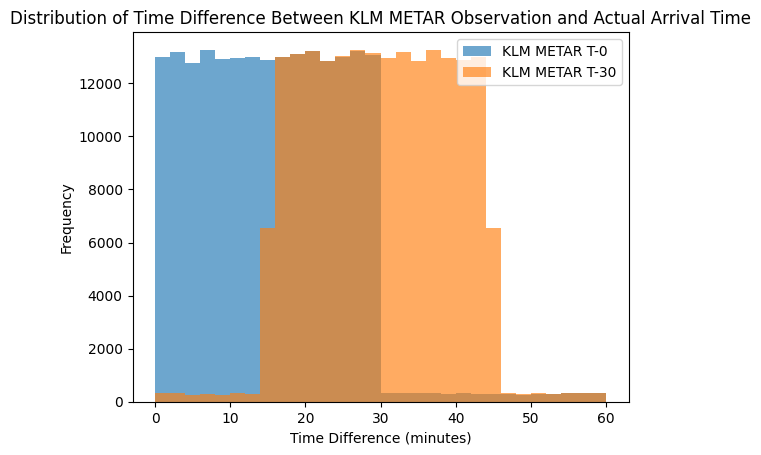

In [7]:
fig, ax = plt.subplots()

ax.hist(
    klm_metar_df.filter(pl.col("has_klm_t0_metar_report") == 1).select(pl.col("klm_t0_metar_ata_diff_minutes")).to_series(),
    bins=30,
    alpha=0.65,
    linewidth=1,
    label='KLM METAR T-0'
)
ax.hist(
    klm_metar_df.filter(pl.col("has_klm_t30_metar_report") == 1).select(pl.col("klm_t30_metar_ata_diff_minutes")).to_series(),
    bins=30,
    alpha=0.65,
    linewidth=1,
    label='KLM METAR T-30'
)

ax.set_title('Distribution of Time Difference Between KLM METAR Observation and Actual Arrival Time')
ax.set_xlabel('Time Difference (minutes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

## Extract IOWA Environment Mesonet (IEM) METAR Data

We further retrieve historical METAR reports sourced from the [Iowa Environmental Mesonet (IEM)](https://mesonet.agron.iastate.edu/request/download.phtml), to supplement data not avaiable form internal sources.

The process works in three steps:

1. **Index** — extract the unique arrival airports and their date ranges directly from the flight dataset.
2. **Bulk fetch** — for each airport, download all METAR observations covering that date range in a single HTTP request to the IEM API, rather than making one call per flight.
3. **Match** — join each flight to its nearest METAR observation (within ±1 hour) using a sorted nearest-key join (`merge_asof`), keeping network calls to a minimum.


In [ ]:
from weather.iem_metar.extract import get_airport_weather_date_ranges

# Use the prepared flight_details_df (already restricted to cleaned flights)
airport_date_ranges = get_airport_weather_date_ranges(
    flight_details_df=flight_details_df,
    airport_col="lkpa_arrival_airport_icao_code",
    timestamp_col="fl_actual_arrival_time_utc"
)

for airport, date_range in airport_date_ranges.items():
    logging.info(f"Airport: {airport}, Date Range: {date_range[0]} to {date_range[1]}")

In [ ]:
from weather.iem_metar.cache import build_iem_metar_cache_for_airports

iem_metar_cache = build_iem_metar_cache_for_airports(airport_date_ranges)

In [ ]:
# match records to iem metar data
from weather.iem_metar.match import match_flight_details_with_iem_metar

iem_t0_metar_df = match_flight_details_with_iem_metar(
    flight_details_df=flight_details_df,
    iem_metar_cache=iem_metar_cache,
    target_offset=0,
)

iem_t30_metar_df = match_flight_details_with_iem_metar(
    flight_details_df=flight_details_df,
    iem_metar_cache=iem_metar_cache,
    target_offset=30,
)

In [ ]:
# Join KLM and IEM METAR data
metar_df = klm_metar_df.join(iem_t0_metar_df, on="flight_key_id", how="left").join(iem_t30_metar_df, on="flight_key_id", how="left")

logging.info(f"Combined METAR dataframe: {metar_df.height} rows, {len(metar_df.columns)} columns")
metar_df.head()

In [ ]:
n_flight_details = metar_df.select(pl.col("flight_key_id")).n_unique()
logging.info(f"Number of unique flights in the dataset: {n_flight_details}")

n_iem_obserations_t0 = metar_df.filter(pl.col("has_iem_t0_metar_report") == 1).height
logging.info(f"Number of observations with IEM METAR data at ATA-0: {n_iem_obserations_t0} ({n_iem_obserations_t0 / n_flight_details:.2%})")

n_iem_obserations_t30 = metar_df.filter(pl.col("has_iem_t30_metar_report") == 1).height
logging.info(f"Number of observations with IEM METAR data at ATA-30: {n_iem_obserations_t30} ({n_iem_obserations_t30 / n_flight_details:.2%})")

In [ ]:
fig, ax = plt.subplots()

ax.hist(
    metar_df.filter(pl.col("has_iem_t0_metar_report") == 1).select(pl.col("iem_t0_metar_ata_diff_minutes")).to_series(),
    bins=30,
    alpha=0.65,
    linewidth=1,
    label='IEM METAR ATA-T0'
)

ax.hist(
    metar_df.filter(pl.col("has_iem_t30_metar_report") == 1).select(pl.col("iem_t30_metar_ata_diff_minutes")).to_series(),
    bins=30,
    alpha=0.65,
    linewidth=1,
    label='IEM METAR ATA-T30'
)

ax.set_title('Distribution of Time Difference Between METAR Observation and Actual Arrival Time')
ax.set_xlabel('Time Difference (minutes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

## KLM vs. IEM Data

In [ ]:
from weather.evaluate_data import evaluate_metar_data_quality

metar_quality_summary_df, metar_quality_by_airport_df = evaluate_metar_data_quality(metar_df)

In [ ]:
from itables import show

def build_metar_quality_table(quality_df: pl.DataFrame, target_offset: int) -> None:
    target_tag = f"t{target_offset}"
    table = (
        quality_df.filter(pl.col("target") == target_tag)
        .with_columns([
            (pl.col("pct_klm_metar_available") * 100).round(1).alias("KLM available (%)"),
            (pl.col("pct_iem_metar_available") * 100).round(1).alias("IEM available (%)"),
            (pl.col("pct_reports_equal_of_both_present") * 100).round(1).alias("Agreement (%)"),
        ])
        .with_columns(
            (pl.col("KLM available (%)") - pl.col("IEM available (%)")).abs().round(1).alias("Source divergence (pp)")
        )
        .select([
            pl.col("lkpa_arrival_airport_icao_code").alias("Airport (ICAO)"),
            pl.col("fl_arrival_airport").alias("Airport (IATA)"),
            pl.col("num_records_extracted").alias("Records"),
            "KLM available (%)",
            "IEM available (%)",
            "Source divergence (pp)",
            "Agreement (%)",
        ])
        .sort("Records", descending=True)
    )

    show(
        table,
        style="width:100%",
        classes="display compact",
        order=[[2, "desc"]],
        caption=f"METAR Source Quality by Airport (ATA-{target_tag.upper()})"
    )

build_metar_quality_table(metar_quality_by_airport_df, target_offset=0)

In [ ]:
build_metar_quality_table(metar_quality_by_airport_df, target_offset=30)

## Machine Learning Feature Extraction

The Metafora (https://github.com/ramondalmau/metafora) python library will be used to extract useful machine learning features from the different METAR messages.

In [8]:
from weather.extract_features import extract_ml_features_from_weather_report

metar_df = klm_metar_df
weather_features_df = metar_df

weather_features_df, _ = extract_ml_features_from_weather_report(
    weather_df=metar_df,
    report_col="klm_t0_metar_report",
    timestamp_col="klm_t0_metar_obs_timestamp",
    insert_before_col="has_klm_t0_metar_report",
    report_type="METAR"
)

weather_features_df, _ = extract_ml_features_from_weather_report(
    weather_df=weather_features_df,
    report_col="klm_t30_metar_report",
    timestamp_col="klm_t30_metar_obs_timestamp",
    insert_before_col="has_klm_t30_metar_report",
    report_type="METAR"
)

# weather_features_df, _ = extract_ml_features_from_weather_report(
#     weather_df=weather_features_df,
#     report_col="iem_t0_metar_report",
#     timestamp_col="iem_t0_metar_obs_timestamp",
#     insert_before_col="has_iem_t0_metar_report",
#     report_type="METAR"
# )

# weather_features_df, _ = extract_ml_features_from_weather_report(
#     weather_df=weather_features_df,
#     report_col="iem_t30_metar_report",
#     timestamp_col="iem_t30_metar_obs_timestamp",
#     insert_before_col="has_iem_t30_metar_report",
#     report_type="METAR"
# )

weather_features_df.head()

c:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-15 12:05:49,940 - INFO - Parsing 200075 METAR reports from column 'klm_t0_metar_report'...
2026-05-15 12:05:49,946 - INFO - Using 12 parallel workers to parse METAR reports in 49 chunks of ~4168 records each.
Parsing METAR (klm_t0_metar_report): 100%|██████████| 200075/200075 [00:30<00:00, 6649.46report/s] 
2026-05-15 12:06:53,292 - INFO - Extracted 25 METAR feature columns from klm_t0_metar_report: klm_t0_metar_station, klm_t0_metar_visibility_cavok, klm_t0_metar_visibility_distance, klm_t0_metar_clouds_height, klm_t0_metar_clouds_amount, klm_t0_metar_clouds_vertical_visibility, klm_t0_metar_wind_speed, klm_t0_metar_wind_gust, klm_t0_metar_wind_compass, klm_t0_metar_wind_shear, klm_t0_

flight_key_id,fl_scheduled_arrival_time_utc,fl_actual_arrival_time_utc,fl_departure_airport,fl_arrival_airport,lkpa_arrival_airport_icao_code,klm_t0_metar_report,klm_t0_metar_timestamp,klm_t0_metar_obs_timestamp,klm_t0_metar_target_diff_minutes,klm_t0_metar_ata_diff_minutes,klm_t0_metar_station,klm_t0_metar_visibility_cavok,klm_t0_metar_visibility_distance,klm_t0_metar_clouds_height,klm_t0_metar_clouds_amount,klm_t0_metar_clouds_vertical_visibility,klm_t0_metar_wind_speed,klm_t0_metar_wind_gust,klm_t0_metar_wind_compass,klm_t0_metar_wind_shear,klm_t0_metar_time,klm_t0_metar_precipitation,klm_t0_metar_obscuration,klm_t0_metar_other,klm_t0_metar_thunderstorms,klm_t0_metar_freezing,klm_t0_metar_showers,klm_t0_metar_snow,klm_t0_metar_ice,klm_t0_metar_hail,klm_t0_metar_fog,klm_t0_metar_clouds,klm_t0_metar_temperature_temperature,klm_t0_metar_temperature_dewpoint,klm_t0_metar_pressure,has_klm_t0_metar_report,…,fl_prev_leg,fl_prev_leg_sibt_utc,fl_prev_leg_aibt_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fp_flight_plan_timestamp_utc,fp_planned_arrival_runway,fl_great_circle_distance_nm,fp_cost_index,fp_route_waypoints,fl_estimated_touchdown_time_utc,fl_actual_touchdown_time_utc_1,fl_touchdown_delay_min,has_flight_plan_data,departure_hour,departure_dayofweek,departure_month,arrival_hour,arrival_dayofweek,arrival_month,actual_arrival_hour,actual_arrival_dayofweek,actual_arrival_month,estimated_touchdown_hour,estimated_touchdown_dayofweek,estimated_touchdown_month,actual_touchdown_hour,actual_touchdown_dayofweek,actual_touchdown_month,prev_scheduled_arrival_hour,prev_scheduled_arrival_dayofweek,prev_scheduled_arrival_month,prev_actual_arrival_hour,prev_actual_arrival_dayofweek,prev_actual_arrival_month,fp_lead_time_min
str,"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,str,bool,f64,i64,f64,f64,f64,f64,str,bool,"datetime[μs, UTC]",bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,i64,…,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,datetime[μs],str,i64,i64,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i32,str,i32,i32,str,i32,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64
"""2025-05-23|KL|0678||YYC""",2025-05-24 05:50:00 UTC,2025-05-24 06:56:00 UTC,"""YYC""","""AMS""","""EHAM""","""EHAM 240655 22013KT 9999 FEW01…",2025-05-24 07:00:52.451 UTC,2025-05-24 06:55:00 UTC,1,1,"""EHAM""",false,9999.0,3048,4.0,null,6.69,0.0,"""SW""",null,2025-05-24 06:55:00 UTC,false,false,false,false,false,false,false,false,false,false,false,13.0,8.0,1012.0,1,…,"""2025-05-23|KL|0677||AMS""",2025-05-23 19:20:00 UTC,2025-05-23 20:15:00 UTC,55,-1,15,2025-05-23 19:05:32.542,"""18R""",3871,220,"""CYYC,AVROM,OBTAD,T_O_C,MAPUX,T…",2025-05-24 06:46:00 UTC,2025-05-24 06:47:00 UTC,1,1,21,"""Friday""",5,5,"""Saturday""",5,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,19.0,"""Friday""",5.0,20.0,"""Friday""",5.0,-129.457633
"""2025-05-03|KL|1197||AMS""",2025-05-03 06:45:00 UTC,2025-05-03 06:35:00 UTC,"""AMS""","""OSL""","""ENGM""","""ENGM 030620 12003KT 040V150 CA…",2025-05-03 06:24:42.974 UTC,2025-05-03 06:20:00 UTC,15,15,"""ENGM""",true,9999.0,3048,null,null,1.54,0.0,"""ESE""",null,2025-05-03 06:20:00 UTC,false,false,false,false,false,false,false,false,false,false,false,8.0,0.0,1001.0,1,…,"""2025-05-02|KL|1154||TRD""",2025-05-02 17:20:00 UTC,2025-05-02 17:17:00 UTC,-3,-8,10,2025-05-03 02:42:51.973,"""01R""",518,20,"""EHAM,ANDIK,KEKIX,T_O_C,AGISU,T…",2025-05-03 06:38:00 UTC,2025-05-03 06:30:00 UTC,-8,1,4,"""Saturday""",5,6,"""Saturday""",5,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,6.0,"""Saturday""",5.0,17.0,"""Friday""",5.0,17.0,"""Friday""",5.0,-132.133783
"""2025-01-28|KL|1164||BGO""",2025-01-28 10:45:00 UTC,2025-01-28 10:41:00 UTC,"""BGO""","""AMS""","""EHAM""","""EHAM 281025 18017KT 9999 -DZRA…",2025-01-28 10:32:00.927 UTC,2025-01-28 10:25:00 UTC,16,16,"""EHAM""",false,9999.0,732,6.0,null,8.75,0.0

In [9]:
weather_features_df.describe()

statistic,flight_key_id,fl_scheduled_arrival_time_utc,fl_actual_arrival_time_utc,fl_departure_airport,fl_arrival_airport,lkpa_arrival_airport_icao_code,klm_t0_metar_report,klm_t0_metar_timestamp,klm_t0_metar_obs_timestamp,klm_t0_metar_target_diff_minutes,klm_t0_metar_ata_diff_minutes,klm_t0_metar_station,klm_t0_metar_visibility_cavok,klm_t0_metar_visibility_distance,klm_t0_metar_clouds_height,klm_t0_metar_clouds_amount,klm_t0_metar_clouds_vertical_visibility,klm_t0_metar_wind_speed,klm_t0_metar_wind_gust,klm_t0_metar_wind_compass,klm_t0_metar_wind_shear,klm_t0_metar_time,klm_t0_metar_precipitation,klm_t0_metar_obscuration,klm_t0_metar_other,klm_t0_metar_thunderstorms,klm_t0_metar_freezing,klm_t0_metar_showers,klm_t0_metar_snow,klm_t0_metar_ice,klm_t0_metar_hail,klm_t0_metar_fog,klm_t0_metar_clouds,klm_t0_metar_temperature_temperature,klm_t0_metar_temperature_dewpoint,klm_t0_metar_pressure,…,fl_prev_leg,fl_prev_leg_sibt_utc,fl_prev_leg_aibt_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fp_flight_plan_timestamp_utc,fp_planned_arrival_runway,fl_great_circle_distance_nm,fp_cost_index,fp_route_waypoints,fl_estimated_touchdown_time_utc,fl_actual_touchdown_time_utc_1,fl_touchdown_delay_min,has_flight_plan_data,departure_hour,departure_dayofweek,departure_month,arrival_hour,arrival_dayofweek,arrival_month,actual_arrival_hour,actual_arrival_dayofweek,actual_arrival_month,estimated_touchdown_hour,estimated_touchdown_dayofweek,estimated_touchdown_month,actual_touchdown_hour,actual_touchdown_dayofweek,actual_touchdown_month,prev_scheduled_arrival_hour,prev_scheduled_arrival_dayofweek,prev_scheduled_arrival_month,prev_actual_arrival_hour,prev_actual_arrival_dayofweek,prev_actual_arrival_month,fp_lead_time_min
str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,str,str,str,f64,f64,f64,str,str,f64,f64,str,str,str,f64,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64
"""count""","""200634""","""200634""","""200634""","""200634""","""200634""","""200634""","""200075""","""200075""","""200075""",200075.0,200075.0,"""200075""",200075.0,200071.0,200075.0,128648.0,712.0,200068.0,200070.0,"""200068""",212.0,"""200075""",200075.0,200075.0,200075.0,200075.0,200075.0,200075.0,200075.0,200075.0,200075.0,200075.0,200075.0,200065.0,200065.0,200066.0,…,"""200560""","""200634""","""200634""",200634.0,200634.0,200634.0,"""200634""","""200634""",200634.0,200634.0,"""200634""","""200634""","""200634""",200634.0,200634.0,200634.0,"""200634""",200634.0,200634.0,"""200634""",200634.0,200634.0,"""200634""",200634.0,200634.0,"""200634""",200634.0,200634.0,"""200634""",200634.0,200634.0,"""200634""",200634.0,200634.0,"""200634""",200634.0,200634.0
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""","""559""","""559""","""559""",559.0,559.0,"""559""",559.0,563.0,559.0,71986.0,199922.0,566.0,564.0,"""566""",200422.0,"""559""",559.0,559.0,559.0,559.0,559.0,559.0,559.0,559.0,559.0,559.0,559.0,569.0,569.0,568.0,…,"""74""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""",0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,0.0
"""mean""",null,"""2025-07-04 17:41:59.928228+00:…","""2025-07-04 17:47:54.729208+00:…",null,null,null,null,"""2025-07-04 18:09:11.932274+00:…","""2025-07-04 18:01:58.943196+00:…",15.206323,15.206323,null,0.302147,9472.911262,2375.231293,4.466871,85.793539,4.385849,0.348181,null,1.0,"""2025-07-04 18:01:58.943196+00:…",0.114557,0.050311,0.00003,0.002589,0.002774,0.054669,0.004743,0.00015,0.000615,0.019393,0.083319,13.49284,8.002744,1015.573901,…,null,"""2025-07-04 12:11:00.515565+00:…","""2025-07-04 12:17:35.167319+00:…",6.577529,-3.707313,258.513971,"""2025-07-04 12:58:48.034193""",null,918.579099,35.002278,null,"""2025-07-04 17:41:44.388887+00:…","""2025-07-04 17:

In [10]:
# Print total number of flights in the dataset and how many have KLM METAR data at T0 and T30
n_flight_details = weather_features_df.select(pl.col("flight_key_id")).n_unique()
n_klm_t0 = weather_features_df.filter(pl.col("has_klm_t0_metar_report") == 1).height
n_klm_t30 = weather_features_df.filter(pl.col("has_klm_t30_metar_report") == 1).height
logging.info(f"Total flights: {n_flight_details}, with KLM T0 METAR: {n_klm_t0}, with KLM T30 METAR: {n_klm_t30}")

2026-05-15 12:08:18,373 - INFO - Total flights: 200634, with KLM T0 METAR: 200075, with KLM T30 METAR: 200075


In [11]:
# Save the combined METAR dataset for future analysis (optional)
output_path = PROCESSED_DATA_PATH / "klm_metar_features_2025.parquet"
weather_features_df.write_parquet(output_path)

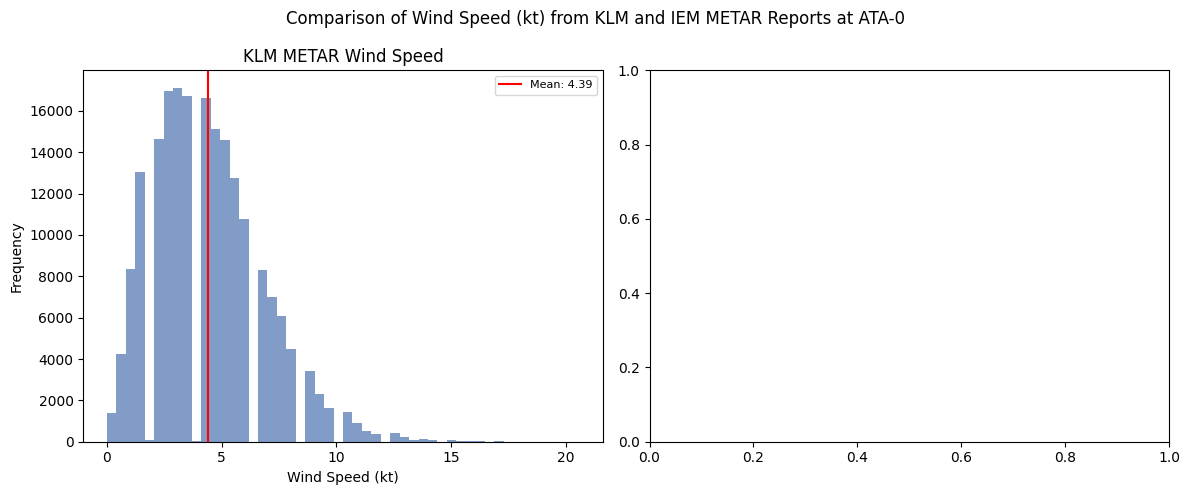

In [12]:
# Feature comparison function (plots histograms of the two distributions side by side with mean lines)
def __plot_feature_comparison(df, col_a, col_b, label_a, label_b, title, distribution_xlabel, color_index=0):
    import numpy as _np
    colors = ['#4C72B0', '#DD8452', '#2ca02c', '#9467bd', '#8c564b']
    vals_a = df[col_a].drop_nulls().to_numpy() if col_a in df.columns else _np.array([])
    vals_b = df[col_b].drop_nulls().to_numpy() if col_b in df.columns else _np.array([])
    if not len(vals_a) and not len(vals_b):
        print(f'Columns {col_a!r} / {col_b!r} not found — skipping plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for i, (ax, vals, label) in enumerate(zip(axes, [vals_a, vals_b], [label_a, label_b])):
        if not len(vals):
            continue
        c = colors[(color_index + i) % len(colors)]
        ax.hist(vals, bins=50, alpha=0.7, color=c)
        ax.axvline(float(vals.mean()), color='red', linewidth=1.5,
                   label=f'Mean: {float(vals.mean()):.2f}')
        ax.set_xlabel(distribution_xlabel)
        ax.set_ylabel('Frequency')
        ax.set_title(label)
        ax.legend(fontsize=8)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

__plot_feature_comparison(
    df=weather_features_df,
    col_a="klm_t0_metar_wind_speed",
    col_b="iem_t0_metar_wind_speed",
    label_a="KLM METAR Wind Speed",
    label_b="IEM METAR Wind Speed",
    title="Comparison of Wind Speed (kt) from KLM and IEM METAR Reports at ATA-0",
    distribution_xlabel="Wind Speed (kt)",
    color_index=0
)

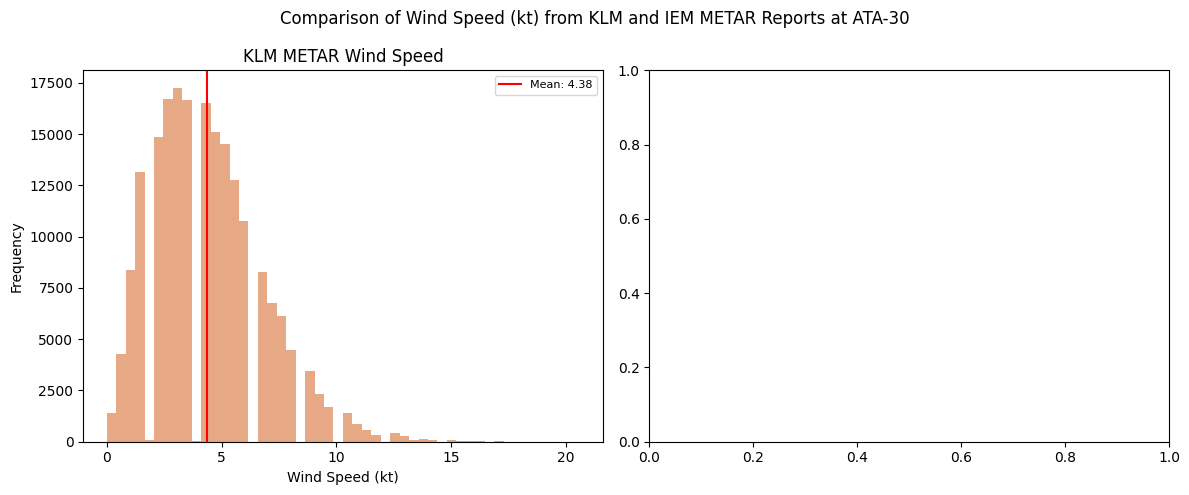

In [13]:
__plot_feature_comparison(
    df=weather_features_df,
    col_a="klm_t30_metar_wind_speed",
    col_b="iem_t30_metar_wind_speed",
    label_a="KLM METAR Wind Speed",
    label_b="IEM METAR Wind Speed",
    title="Comparison of Wind Speed (kt) from KLM and IEM METAR Reports at ATA-30",
    distribution_xlabel="Wind Speed (kt)",
    color_index=1
)

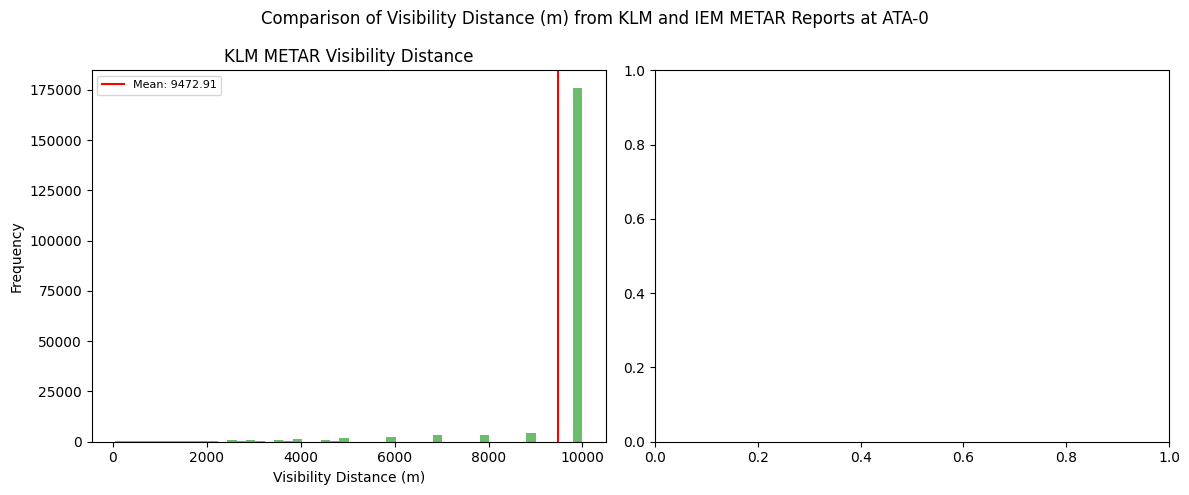

In [14]:
__plot_feature_comparison(
    df=weather_features_df,
    col_a="klm_t0_metar_visibility_distance",
    col_b="iem_t0_metar_visibility_distance",
    label_a="KLM METAR Visibility Distance",
    label_b="IEM METAR Visibility Distance",
    title="Comparison of Visibility Distance (m) from KLM and IEM METAR Reports at ATA-0",
    distribution_xlabel="Visibility Distance (m)",
    color_index=2
)

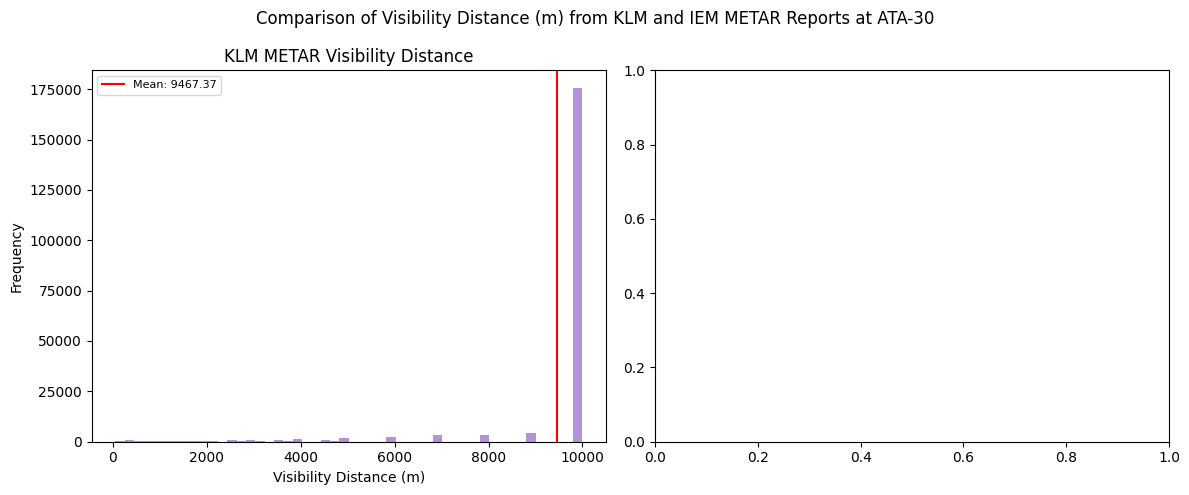

In [15]:
__plot_feature_comparison(
    df=weather_features_df,
    col_a="klm_t30_metar_visibility_distance",
    col_b="iem_t30_metar_visibility_distance",
    label_a="KLM METAR Visibility Distance",
    label_b="IEM METAR Visibility Distance",
    title="Comparison of Visibility Distance (m) from KLM and IEM METAR Reports at ATA-30",
    distribution_xlabel="Visibility Distance (m)",
    color_index=3
)

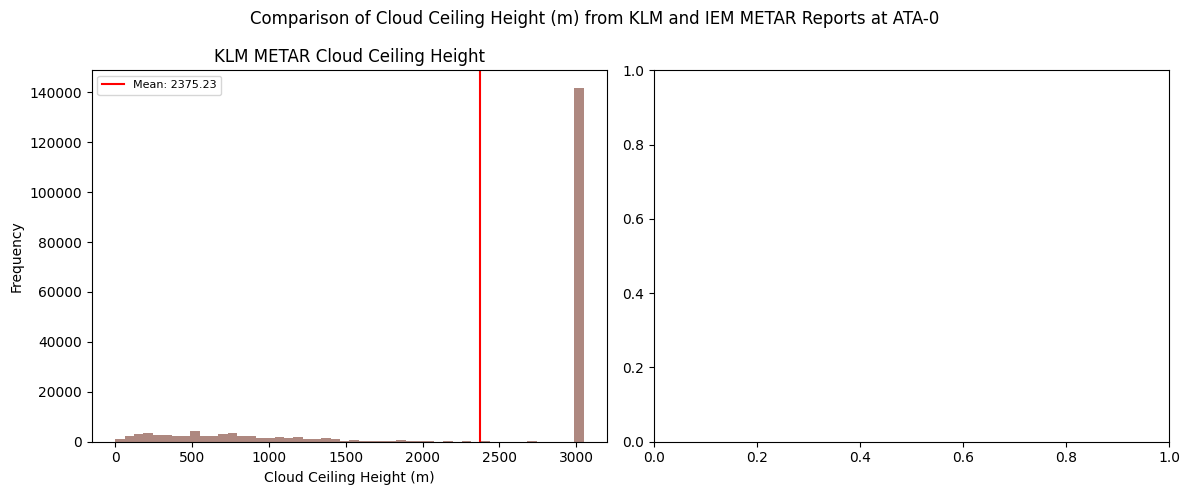

In [16]:
__plot_feature_comparison(
    df=weather_features_df,
    col_a="klm_t0_metar_clouds_height",
    col_b="iem_t0_metar_clouds_height",
    label_a="KLM METAR Cloud Ceiling Height",
    label_b="IEM METAR Cloud Ceiling Height",
    title="Comparison of Cloud Ceiling Height (m) from KLM and IEM METAR Reports at ATA-0",
    distribution_xlabel="Cloud Ceiling Height (m)",
    color_index=4
)

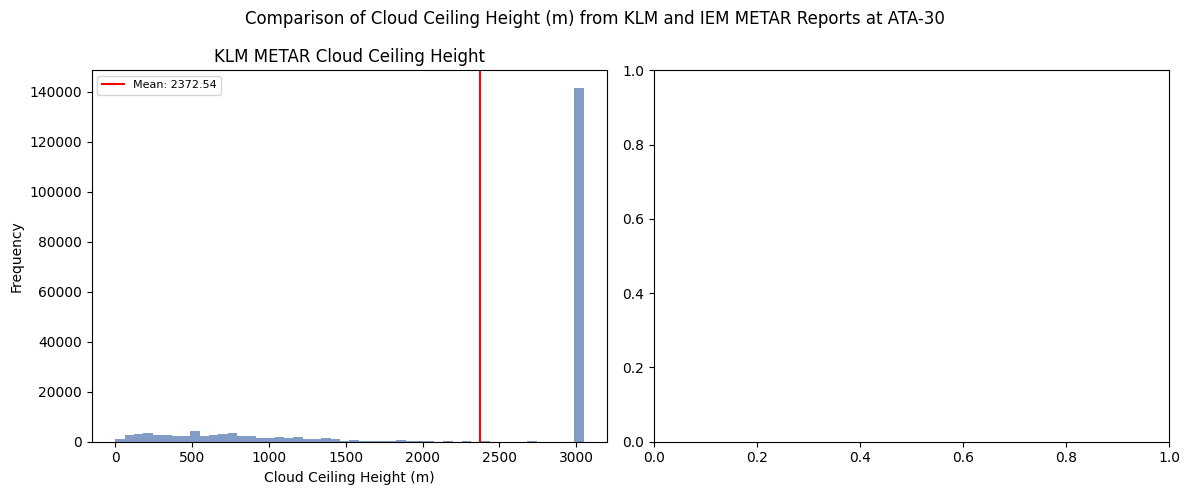

In [17]:
__plot_feature_comparison(
    df=weather_features_df,
    col_a="klm_t30_metar_clouds_height",
    col_b="iem_t30_metar_clouds_height",
    label_a="KLM METAR Cloud Ceiling Height",
    label_b="IEM METAR Cloud Ceiling Height",
    title="Comparison of Cloud Ceiling Height (m) from KLM and IEM METAR Reports at ATA-30",
    distribution_xlabel="Cloud Ceiling Height (m)",
    color_index=5
)


## Missing Data Analysis

Investigate which flights are missing METAR data, from which airports, and whether missingness is random or systematic.


shape: (2, 4)
┌─────────┬───────────┬─────────┬───────────────┐
│ Source  ┆ Available ┆ Missing ┆ Pct Available │
│ ---     ┆ ---       ┆ ---     ┆ ---           │
│ str     ┆ i64       ┆ i64     ┆ f64           │
╞═════════╪═══════════╪═════════╪═══════════════╡
│ KLM T0  ┆ 200075    ┆ 559     ┆ 99.7          │
│ KLM T30 ┆ 200075    ┆ 559     ┆ 99.7          │
└─────────┴───────────┴─────────┴───────────────┘


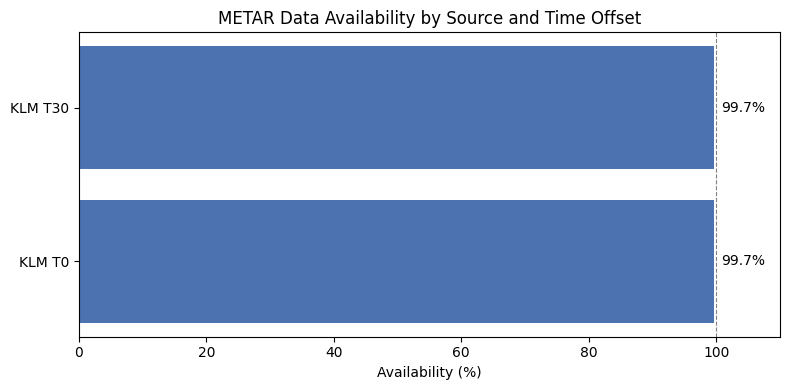

In [18]:
import numpy as np

n_total = weather_features_df.height

# Define availability flags: a flight "has" data when at least one of KLM or IEM is present
missing_stats = []
for tag, label in [("klm_t0", "KLM T0"), ("klm_t30", "KLM T30")]: #,
                #    ("iem_t0", "IEM T0"), ("iem_t30", "IEM T30")]:
    n_avail = weather_features_df.filter(pl.col(f"has_{tag}_metar_report") == 1).height
    missing_stats.append({
        "Source": label,
        "Available": n_avail,
        "Missing": n_total - n_avail,
        "Pct Available": round(n_avail / n_total * 100, 1),
    })

missing_summary_df = pl.DataFrame(missing_stats)
print(missing_summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
sources = [r["Source"] for r in missing_stats]
pcts = [r["Pct Available"] for r in missing_stats]
bars = ax.barh(sources, pcts, color=["#4C72B0", "#4C72B0", "#DD8452", "#DD8452"])
ax.set_xlim(0, 110)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=10)
ax.set_xlabel("Availability (%)")
ax.set_title("METAR Data Availability by Source and Time Offset")
ax.axvline(100, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

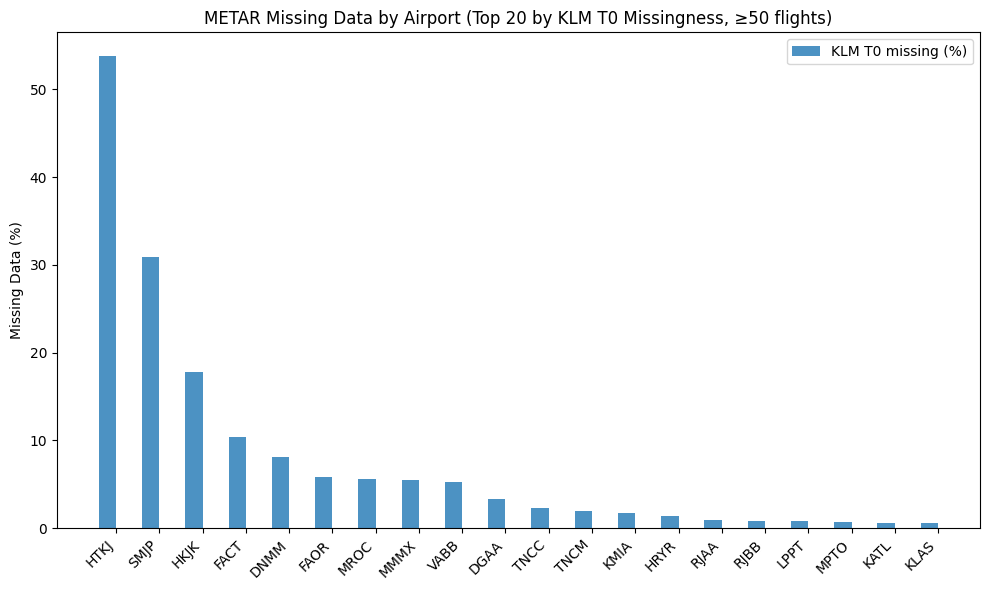

In [19]:
# Missing data by arrival airport (KLM T0 as representative)
missing_by_airport = (
    weather_features_df
    .group_by("lkpa_arrival_airport_icao_code")
    .agg(
        pl.len().alias("n_flights"),
        (pl.col("has_klm_t0_metar_report") == 1).sum().alias("n_klm_t0"),
        # (pl.col("has_iem_t0_metar_report") == 1).sum().alias("n_iem_t0"),
    )
    .with_columns([
        (1 - pl.col("n_klm_t0") / pl.col("n_flights")).alias("pct_missing_klm_t0"),
        # (1 - pl.col("n_iem_t0") / pl.col("n_flights")).alias("pct_missing_iem_t0"),
    ])
    .filter(pl.col("n_flights") >= 50)
    .sort("pct_missing_klm_t0", descending=True)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
airports = missing_by_airport["lkpa_arrival_airport_icao_code"].to_list()
x = np.arange(len(airports))
width = 0.4

ax.bar(x - width/2, (missing_by_airport["pct_missing_klm_t0"] * 100).to_list(),
       width, label="KLM T0 missing (%)", alpha=0.8)
# ax.bar(x + width/2, (missing_by_airport["pct_missing_iem_t0"] * 100).to_list(),
#        width, label="IEM T0 missing (%)", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(airports, rotation=45, ha="right")
ax.set_ylabel("Missing Data (%)")
ax.set_title("METAR Missing Data by Airport (Top 20 by KLM T0 Missingness, ≥50 flights)")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Print number of flights with missing KLM T0 and T30 METAR data for arrivals to AMS
ams_flights = weather_features_df.filter(pl.col("lkpa_arrival_airport_icao_code") == "EHAM")
n_ams_flights = ams_flights.height
n_ams_missing_t0 = ams_flights.filter(pl.col("has_klm_t0_metar_report") == 0).height
n_ams_missing_t30 = ams_flights.filter(pl.col("has_klm_t30_metar_report") == 0).height
logging.info(f"AMS arrivals: {n_ams_flights} flights, {n_ams_missing_t0} missing KLM T0 METAR, {n_ams_missing_t30} missing KLM T30 METAR")

2026-05-15 12:09:09,645 - INFO - AMS arrivals: 101440 flights, 91 missing KLM T0 METAR, 91 missing KLM T30 METAR


In [21]:
metar_feature_cols = [
"klm_t0_metar_visibility_cavok",
"klm_t0_metar_visibility_distance",
"klm_t0_metar_clouds_height",
"klm_t0_metar_clouds_amount",
"klm_t0_metar_clouds_vertical_visibility",
"klm_t0_metar_wind_speed",
"klm_t0_metar_wind_gust",
"klm_t0_metar_wind_compass",
"klm_t0_metar_wind_shear",
"klm_t0_metar_precipitation",
"klm_t0_metar_obscuration",
"klm_t0_metar_other",
"klm_t0_metar_thunderstorms",
"klm_t0_metar_freezing",
"klm_t0_metar_showers",
"klm_t0_metar_snow",
"klm_t0_metar_ice",
"klm_t0_metar_hail",
"klm_t0_metar_fog",
"klm_t0_metar_clouds",
"klm_t0_metar_temperature_temperature",
"klm_t0_metar_temperature_dewpoint",
"klm_t0_metar_pressure",
"klm_t30_metar_visibility_cavok",
"klm_t30_metar_visibility_distance",
"klm_t30_metar_clouds_height",
"klm_t30_metar_clouds_amount",
"klm_t30_metar_clouds_vertical_visibility",
"klm_t30_metar_wind_speed",
"klm_t30_metar_wind_gust",
"klm_t30_metar_wind_compass",
"klm_t30_metar_wind_shear",
"klm_t30_metar_precipitation",
"klm_t30_metar_obscuration",
"klm_t30_metar_other",
"klm_t30_metar_thunderstorms",
"klm_t30_metar_freezing",
"klm_t30_metar_showers",
"klm_t30_metar_snow",
"klm_t30_metar_ice",
"klm_t30_metar_hail",
"klm_t30_metar_fog",
"klm_t30_metar_clouds",
"klm_t30_metar_temperature_temperature",
"klm_t30_metar_temperature_dewpoint",
"klm_t30_metar_pressure",
]

feature_summary = []
for col in metar_feature_cols:
    if col not in weather_features_df.columns:
        continue
    n_non_null = weather_features_df.filter(pl.col(col).is_not_null()).height
    feature_summary.append({
    "Feature": col,
    "Non-null count": n_non_null,
    "Non-null %": round(n_non_null / n_total * 100, 1),
    })

feature_summary_df = pl.DataFrame(feature_summary).sort("Non-null count", descending=True)
print(feature_summary_df)

shape: (46, 3)
┌─────────────────────────────────┬────────────────┬────────────┐
│ Feature                         ┆ Non-null count ┆ Non-null % │
│ ---                             ┆ ---            ┆ ---        │
│ str                             ┆ i64            ┆ f64        │
╞═════════════════════════════════╪════════════════╪════════════╡
│ klm_t0_metar_visibility_cavok   ┆ 200075         ┆ 99.7       │
│ klm_t0_metar_clouds_height      ┆ 200075         ┆ 99.7       │
│ klm_t0_metar_precipitation      ┆ 200075         ┆ 99.7       │
│ klm_t0_metar_obscuration        ┆ 200075         ┆ 99.7       │
│ klm_t0_metar_other              ┆ 200075         ┆ 99.7       │
│ …                               ┆ …              ┆ …          │
│ klm_t0_metar_clouds_amount      ┆ 128648         ┆ 64.1       │
│ klm_t30_metar_clouds_vertical_… ┆ 733            ┆ 0.4        │
│ klm_t0_metar_clouds_vertical_v… ┆ 712            ┆ 0.4        │
│ klm_t0_metar_wind_shear         ┆ 212            ┆ 0.1     

In [22]:
# Print percentage of times that precipitation, obscuration, thunderstorm, freezing, showers, snow, ice, hail, fog and clouds are not false (i.e. the weather phenomenon is present) in the KLM T0 and T30 METAR reports
phenomena = ["precipitation", "obscuration", "thunderstorms", "freezing", "showers", "snow", "ice", "hail", "fog", "clouds", "visibility_cavok"]
for phenomenon in phenomena:
    for tag in ["klm_t0", "klm_t30"]:
        col = f"{tag}_metar_{phenomenon}"
        if col in weather_features_df.columns:
            n_present = weather_features_df.filter(pl.col(col) == True).height
            logging.info(f"{col}: {n_present} present ({n_present / n_total:.2%})")

2026-05-15 12:09:19,494 - INFO - klm_t0_metar_precipitation: 22920 present (11.42%)
2026-05-15 12:09:19,531 - INFO - klm_t30_metar_precipitation: 23051 present (11.49%)
2026-05-15 12:09:19,558 - INFO - klm_t0_metar_obscuration: 10066 present (5.02%)
2026-05-15 12:09:19,584 - INFO - klm_t30_metar_obscuration: 10323 present (5.15%)
2026-05-15 12:09:19,601 - INFO - klm_t0_metar_thunderstorms: 518 present (0.26%)
2026-05-15 12:09:19,614 - INFO - klm_t30_metar_thunderstorms: 503 present (0.25%)
2026-05-15 12:09:19,626 - INFO - klm_t0_metar_freezing: 555 present (0.28%)
2026-05-15 12:09:19,638 - INFO - klm_t30_metar_freezing: 566 present (0.28%)
2026-05-15 12:09:19,670 - INFO - klm_t0_metar_showers: 10938 present (5.45%)
2026-05-15 12:09:19,697 - INFO - klm_t30_metar_showers: 11010 present (5.49%)
2026-05-15 12:09:19,709 - INFO - klm_t0_metar_snow: 949 present (0.47%)
2026-05-15 12:09:19,719 - INFO - klm_t30_metar_snow: 973 present (0.48%)
2026-05-15 12:09:19,731 - INFO - klm_t0_metar_ice: 3

In [23]:
# Print percentage of flights with postive touchdown delay (i.e. arrived later than scheduled) and how this relates to the availability of KLM T0 and T30 METAR data
n_positive_delay = weather_features_df.filter(pl.col("fl_touchdown_delay_min") > 0).height
logging.info(f"Flights with positive touchdown delay: {n_positive_delay} ({n_positive_delay / n_total:.2%})")

2026-05-15 12:09:24,057 - INFO - Flights with positive touchdown delay: 96836 (48.26%)


In [24]:
adverse_phenomena = [
    "precipitation",
    "obscuration",
    "thunderstorms",
    "freezing",
    "showers",
    "snow",
    "ice",
    "hail",
    "fog",
    "clouds",
]

t0_phenomenon_cols = [
    f"klm_t0_metar_{p}"
    for p in adverse_phenomena
    if f"klm_t0_metar_{p}" in weather_features_df.columns
]

convective_expr = pl.lit(False)

for col in t0_phenomenon_cols:
    convective_expr = convective_expr | (pl.col(col) == True)

ams_df = (
    weather_features_df
    .filter(pl.col("lkpa_arrival_airport_icao_code") == "EHAM")
    .with_columns(convective_expr.alias("convective_weather"))
)

n_ams = ams_df.height
n_convective = ams_df.filter(pl.col("convective_weather")).height
n_no_convective = n_ams - n_convective

logging.info(
    f"AMS arrivals: {n_ams:,} total | "
    f"{n_convective:,} with convective weather ({n_convective/n_ams:.1%}) | "
    f"{n_no_convective:,} without ({n_no_convective/n_ams:.1%})"
)

delay_cols = {
    "Touchdown delay (min)": "fl_touchdown_delay_min",
    "Arrival delay diff (min)": "fl_arrival_delay_difference_min",
    "Departure delay (min)": "fl_departure_delay_difference_min",
    "Trip duration diff (min)": "fl_trip_duration_deviation_min",
}

delay_cols = {
    label: col
    for label, col in delay_cols.items()
    if col in ams_df.columns
}

stats_rows = []

for label, col in delay_cols.items():

    for group_val, group_label in [
        (True, "Convective"),
        (False, "No convective"),
    ]:

        sub = (
            ams_df
            .filter(pl.col("convective_weather") == group_val)[col]
            .drop_nulls()
        )

        n = len(sub)

        if n == 0:
            continue

        arr = sub.to_numpy()

        stats_rows.append({
            "Weather": group_label,
            "Metric": label,
            "n": n,
            "Mean": round(float(arr.mean()), 2),
            "Median": round(float(np.median(arr)), 2),
            "Std": round(float(arr.std()), 2),
            "Pct > 0": round(float((arr > 0).mean() * 100), 1),
        })

stats_df = pl.DataFrame(stats_rows)

print(stats_df)

# ---------------------------------------------------------
# Positive touchdown delay analysis
# ---------------------------------------------------------

if "fl_touchdown_delay_min" in ams_df.columns:

    for group_val, group_label in [
        (True, "Convective weather"),
        (False, "No convective weather"),
    ]:

        sub = ams_df.filter(pl.col("convective_weather") == group_val)

        n_sub = sub.height

        n_pos = (
            sub
            .filter(pl.col("fl_touchdown_delay_min") > 0)
            .height
        )

        logging.info(
            f"[{group_label}] "
            f"n={n_sub:,} | "
            f"positive touchdown delay: "
            f"{n_pos:,} ({n_pos/n_sub:.1%})"
        )

# ---------------------------------------------------------
# Per-phenomenon breakdown
# ---------------------------------------------------------

if "fl_touchdown_delay_min" in ams_df.columns:

    phenom_rows = []

    for p in adverse_phenomena:

        col = f"klm_t0_metar_{p}"

        if col not in ams_df.columns:
            continue

        present = (
            ams_df
            .filter(pl.col(col) == True)["fl_touchdown_delay_min"]
            .drop_nulls()
            .to_numpy()
        )

        absent = (
            ams_df
            .filter(pl.col(col) != True)["fl_touchdown_delay_min"]
            .drop_nulls()
            .to_numpy()
        )

        n_present = (
            ams_df
            .filter(pl.col(col) == True)
            .height
        )

        phenom_rows.append({
            "Phenomenon": p,
            "n_present": n_present,
            "Pct present": round(n_present / n_ams * 100, 1),
            "Mean delay (present)": (
                round(float(present.mean()), 2)
                if len(present)
                else None
            ),
            "Mean delay (absent)": (
                round(float(absent.mean()), 2)
                if len(absent)
                else None
            ),
        })

    phenom_df = (
        pl.DataFrame(phenom_rows)
        .sort("n_present", descending=True)
    )

    print(
        "\nPer-phenomenon breakdown "
        "(AMS T0, mean touchdown delay in min):"
    )

    print(phenom_df)

# ---------------------------------------------------------
# CAVOK vs non-CAVOK analysis
# ---------------------------------------------------------

cavok_col = "klm_t0_metar_visibility_cavok"

if (
    cavok_col in ams_df.columns
    and "fl_touchdown_delay_min" in ams_df.columns
):

    for val, label in [
        (True, "CAVOK (clear)"),
        (False, "Non-CAVOK"),
    ]:

        sub = ams_df.filter(pl.col(cavok_col) == val)

        n_sub = sub.height

        if n_sub == 0:
            continue

        mean_delay = (
            sub["fl_touchdown_delay_min"]
            .drop_nulls()
            .mean()
        )

        n_pos = (
            sub
            .filter(pl.col("fl_touchdown_delay_min") > 0)
            .height
        )

        logging.info(
            f"[{label}] "
            f"n={n_sub:,} ({n_sub/n_ams:.1%}) | "
            f"mean touchdown delay: {mean_delay:.2f} min | "
            f"positive delay: {n_pos/n_sub:.1%}"
        )

2026-05-15 12:09:26,639 - INFO - AMS arrivals: 101,440 total | 24,358 with convective weather (24.0%) | 77,082 without (76.0%)
2026-05-15 12:09:27,017 - INFO - [Convective weather] n=24,358 | positive touchdown delay: 13,852 (56.9%)
2026-05-15 12:09:27,097 - INFO - [No convective weather] n=76,991 | positive touchdown delay: 43,143 (56.0%)


shape: (8, 7)
┌───────────────┬──────────────────────────┬───────┬───────┬────────┬───────┬─────────┐
│ Weather       ┆ Metric                   ┆ n     ┆ Mean  ┆ Median ┆ Std   ┆ Pct > 0 │
│ ---           ┆ ---                      ┆ ---   ┆ ---   ┆ ---    ┆ ---   ┆ ---     │
│ str           ┆ str                      ┆ i64   ┆ f64   ┆ f64    ┆ f64   ┆ f64     │
╞═══════════════╪══════════════════════════╪═══════╪═══════╪════════╪═══════╪═════════╡
│ Convective    ┆ Touchdown delay (min)    ┆ 24358 ┆ 1.02  ┆ 1.0    ┆ 1.99  ┆ 56.9    │
│ No convective ┆ Touchdown delay (min)    ┆ 76991 ┆ 0.89  ┆ 1.0    ┆ 1.82  ┆ 56.0    │
│ Convective    ┆ Arrival delay diff (min) ┆ 24358 ┆ 7.71  ┆ 3.0    ┆ 20.85 ┆ 56.4    │
│ No convective ┆ Arrival delay diff (min) ┆ 76991 ┆ 3.65  ┆ 0.0    ┆ 17.99 ┆ 48.6    │
│ Convective    ┆ Departure delay (min)    ┆ 24358 ┆ 14.22 ┆ 8.0    ┆ 19.75 ┆ 75.1    │
│ No convective ┆ Departure delay (min)    ┆ 76991 ┆ 11.28 ┆ 7.0    ┆ 17.17 ┆ 73.3    │
│ Convective    ┆ 

2026-05-15 12:09:27,475 - INFO - [CAVOK (clear)] n=28,631 (28.2%) | mean touchdown delay: 0.87 min | positive delay: 56.1%
2026-05-15 12:09:27,506 - INFO - [Non-CAVOK] n=72,718 (71.7%) | mean touchdown delay: 0.94 min | positive delay: 56.3%



Per-phenomenon breakdown (AMS T0, mean touchdown delay in min):
shape: (10, 5)
┌───────────────┬───────────┬─────────────┬──────────────────────┬─────────────────────┐
│ Phenomenon    ┆ n_present ┆ Pct present ┆ Mean delay (present) ┆ Mean delay (absent) │
│ ---           ┆ ---       ┆ ---         ┆ ---                  ┆ ---                 │
│ str           ┆ i64       ┆ f64         ┆ f64                  ┆ f64                 │
╞═══════════════╪═══════════╪═════════════╪══════════════════════╪═════════════════════╡
│ precipitation ┆ 13601     ┆ 13.4        ┆ 1.01                 ┆ 0.91                │
│ clouds        ┆ 10858     ┆ 10.7        ┆ 0.66                 ┆ 0.95                │
│ showers       ┆ 7091      ┆ 7.0         ┆ 0.66                 ┆ 0.94                │
│ obscuration   ┆ 5448      ┆ 5.4         ┆ 1.54                 ┆ 0.89                │
│ fog           ┆ 2586      ┆ 2.5         ┆ 1.59                 ┆ 0.9                 │
│ freezing      ┆ 332       ┆ 


## Outlier Detection

Check for extreme or implausible values in extracted weather features.


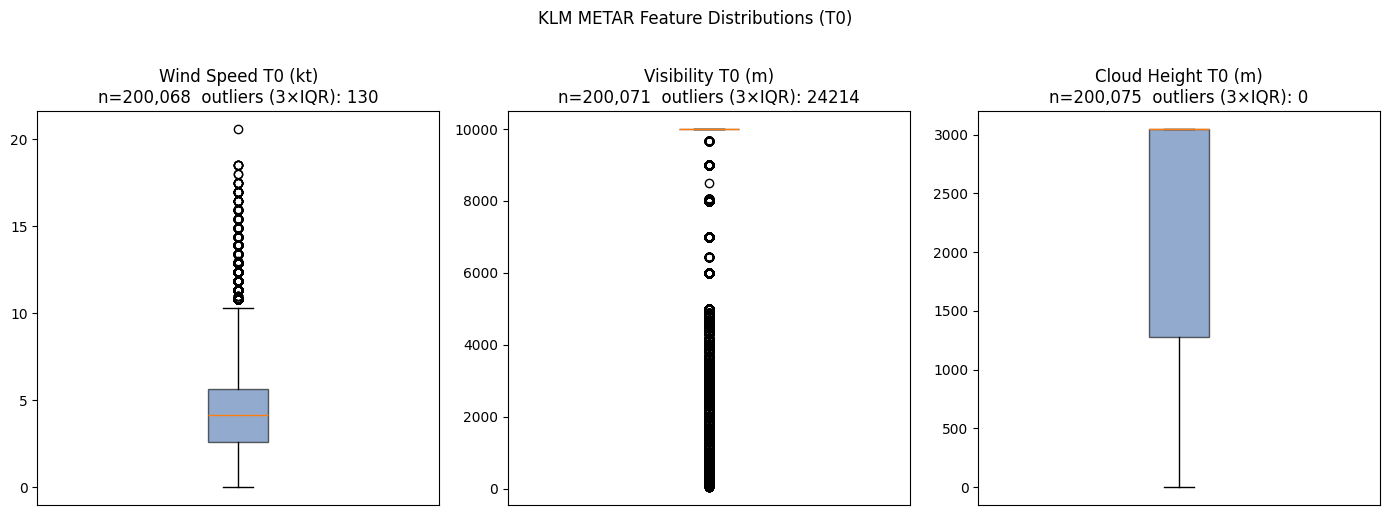

shape: (6, 8)
┌──────────────────────┬─────────┬──────┬─────────┬────────┬────────┬────────┬─────────────────┐
│ Feature              ┆ n_valid ┆ min  ┆ p1      ┆ median ┆ p99    ┆ max    ┆ n_outliers_3iqr │
│ ---                  ┆ ---     ┆ ---  ┆ ---     ┆ ---    ┆ ---    ┆ ---    ┆ ---             │
│ str                  ┆ i64     ┆ f64  ┆ f64     ┆ f64    ┆ f64    ┆ f64    ┆ i64             │
╞══════════════════════╪═════════╪══════╪═════════╪════════╪════════╪════════╪═════════════════╡
│ KLM T0 Wind Speed    ┆ 200068  ┆ 0.0  ┆ 0.51    ┆ 4.12   ┆ 11.32  ┆ 20.58  ┆ 130             │
│ KLM T30 Wind Speed   ┆ 200065  ┆ 0.0  ┆ 0.51    ┆ 4.12   ┆ 11.32  ┆ 20.58  ┆ 126             │
│ KLM T0 Visibility    ┆ 200071  ┆ 50.0 ┆ 1300.0  ┆ 9999.0 ┆ 9999.0 ┆ 9999.0 ┆ 24214           │
│ KLM T30 Visibility   ┆ 200072  ┆ 50.0 ┆ 1204.97 ┆ 9999.0 ┆ 9999.0 ┆ 9999.0 ┆ 24498           │
│ KLM T0 Cloud Height  ┆ 200075  ┆ 0.0  ┆ 61.0    ┆ 3048.0 ┆ 3048.0 ┆ 3048.0 ┆ 0               │
│ KLM T30 Cloud 

In [25]:
# Identify weather feature columns available across KLM and IEM sources
weather_feature_pairs = [
    ("klm_t0_metar_wind_speed",          "Wind Speed T0 (kt)"),
    ("klm_t0_metar_visibility_distance", "Visibility T0 (m)"),
    ("klm_t0_metar_clouds_height",       "Cloud Height T0 (m)"),
]

# Box plots with IQR-based outlier flagging
fig, axes = plt.subplots(1, len(weather_feature_pairs), figsize=(14, 5))
for ax, (col, label) in zip(axes, weather_feature_pairs):
    values = weather_features_df.select(pl.col(col)).drop_nulls().to_series().to_numpy()
    ax.boxplot(values, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.6))
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    n_outliers = int(((values < lower) | (values > upper)).sum())
    ax.set_title(f"{label}\nn={len(values):,}  outliers (3×IQR): {n_outliers}")
    ax.set_xticks([])
plt.suptitle("KLM METAR Feature Distributions (T0)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Tabular summary of outlier counts per feature/source
outlier_rows = []
feature_cols = [
    ("klm_t0_metar_wind_speed",          "KLM T0 Wind Speed"),
    ("klm_t30_metar_wind_speed",         "KLM T30 Wind Speed"),
    # ("iem_t0_metar_wind_speed",          "IEM T0 Wind Speed"),
    # ("iem_t30_metar_wind_speed",         "IEM T30 Wind Speed"),
    ("klm_t0_metar_visibility_distance", "KLM T0 Visibility"),
    ("klm_t30_metar_visibility_distance","KLM T30 Visibility"),
    # ("iem_t0_metar_visibility_distance", "IEM T0 Visibility"),
    ("klm_t0_metar_clouds_height",       "KLM T0 Cloud Height"),
    ("klm_t30_metar_clouds_height",      "KLM T30 Cloud Height"),
    # ("iem_t0_metar_clouds_height",       "IEM T0 Cloud Height"),
]
for col, label in feature_cols:
    if col not in weather_features_df.columns:
        continue
    values = weather_features_df.select(pl.col(col)).drop_nulls().to_series().to_numpy()
    if len(values) == 0:
        continue
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    outlier_rows.append({
        "Feature": label,
        "n_valid": len(values),
        "min": round(float(values.min()), 2),
        "p1": round(float(np.percentile(values, 1)), 2),
        "median": round(float(np.median(values)), 2),
        "p99": round(float(np.percentile(values, 99)), 2),
        "max": round(float(values.max()), 2),
        "n_outliers_3iqr": int(((values < lower) | (values > upper)).sum()),
    })

outlier_summary_df = pl.DataFrame(outlier_rows)
print(outlier_summary_df)


## Weather–Delay Correlations

Examine the relationship between weather features (from METAR observations) and the touchdown delay (`fl_touchdown_delay_min`).


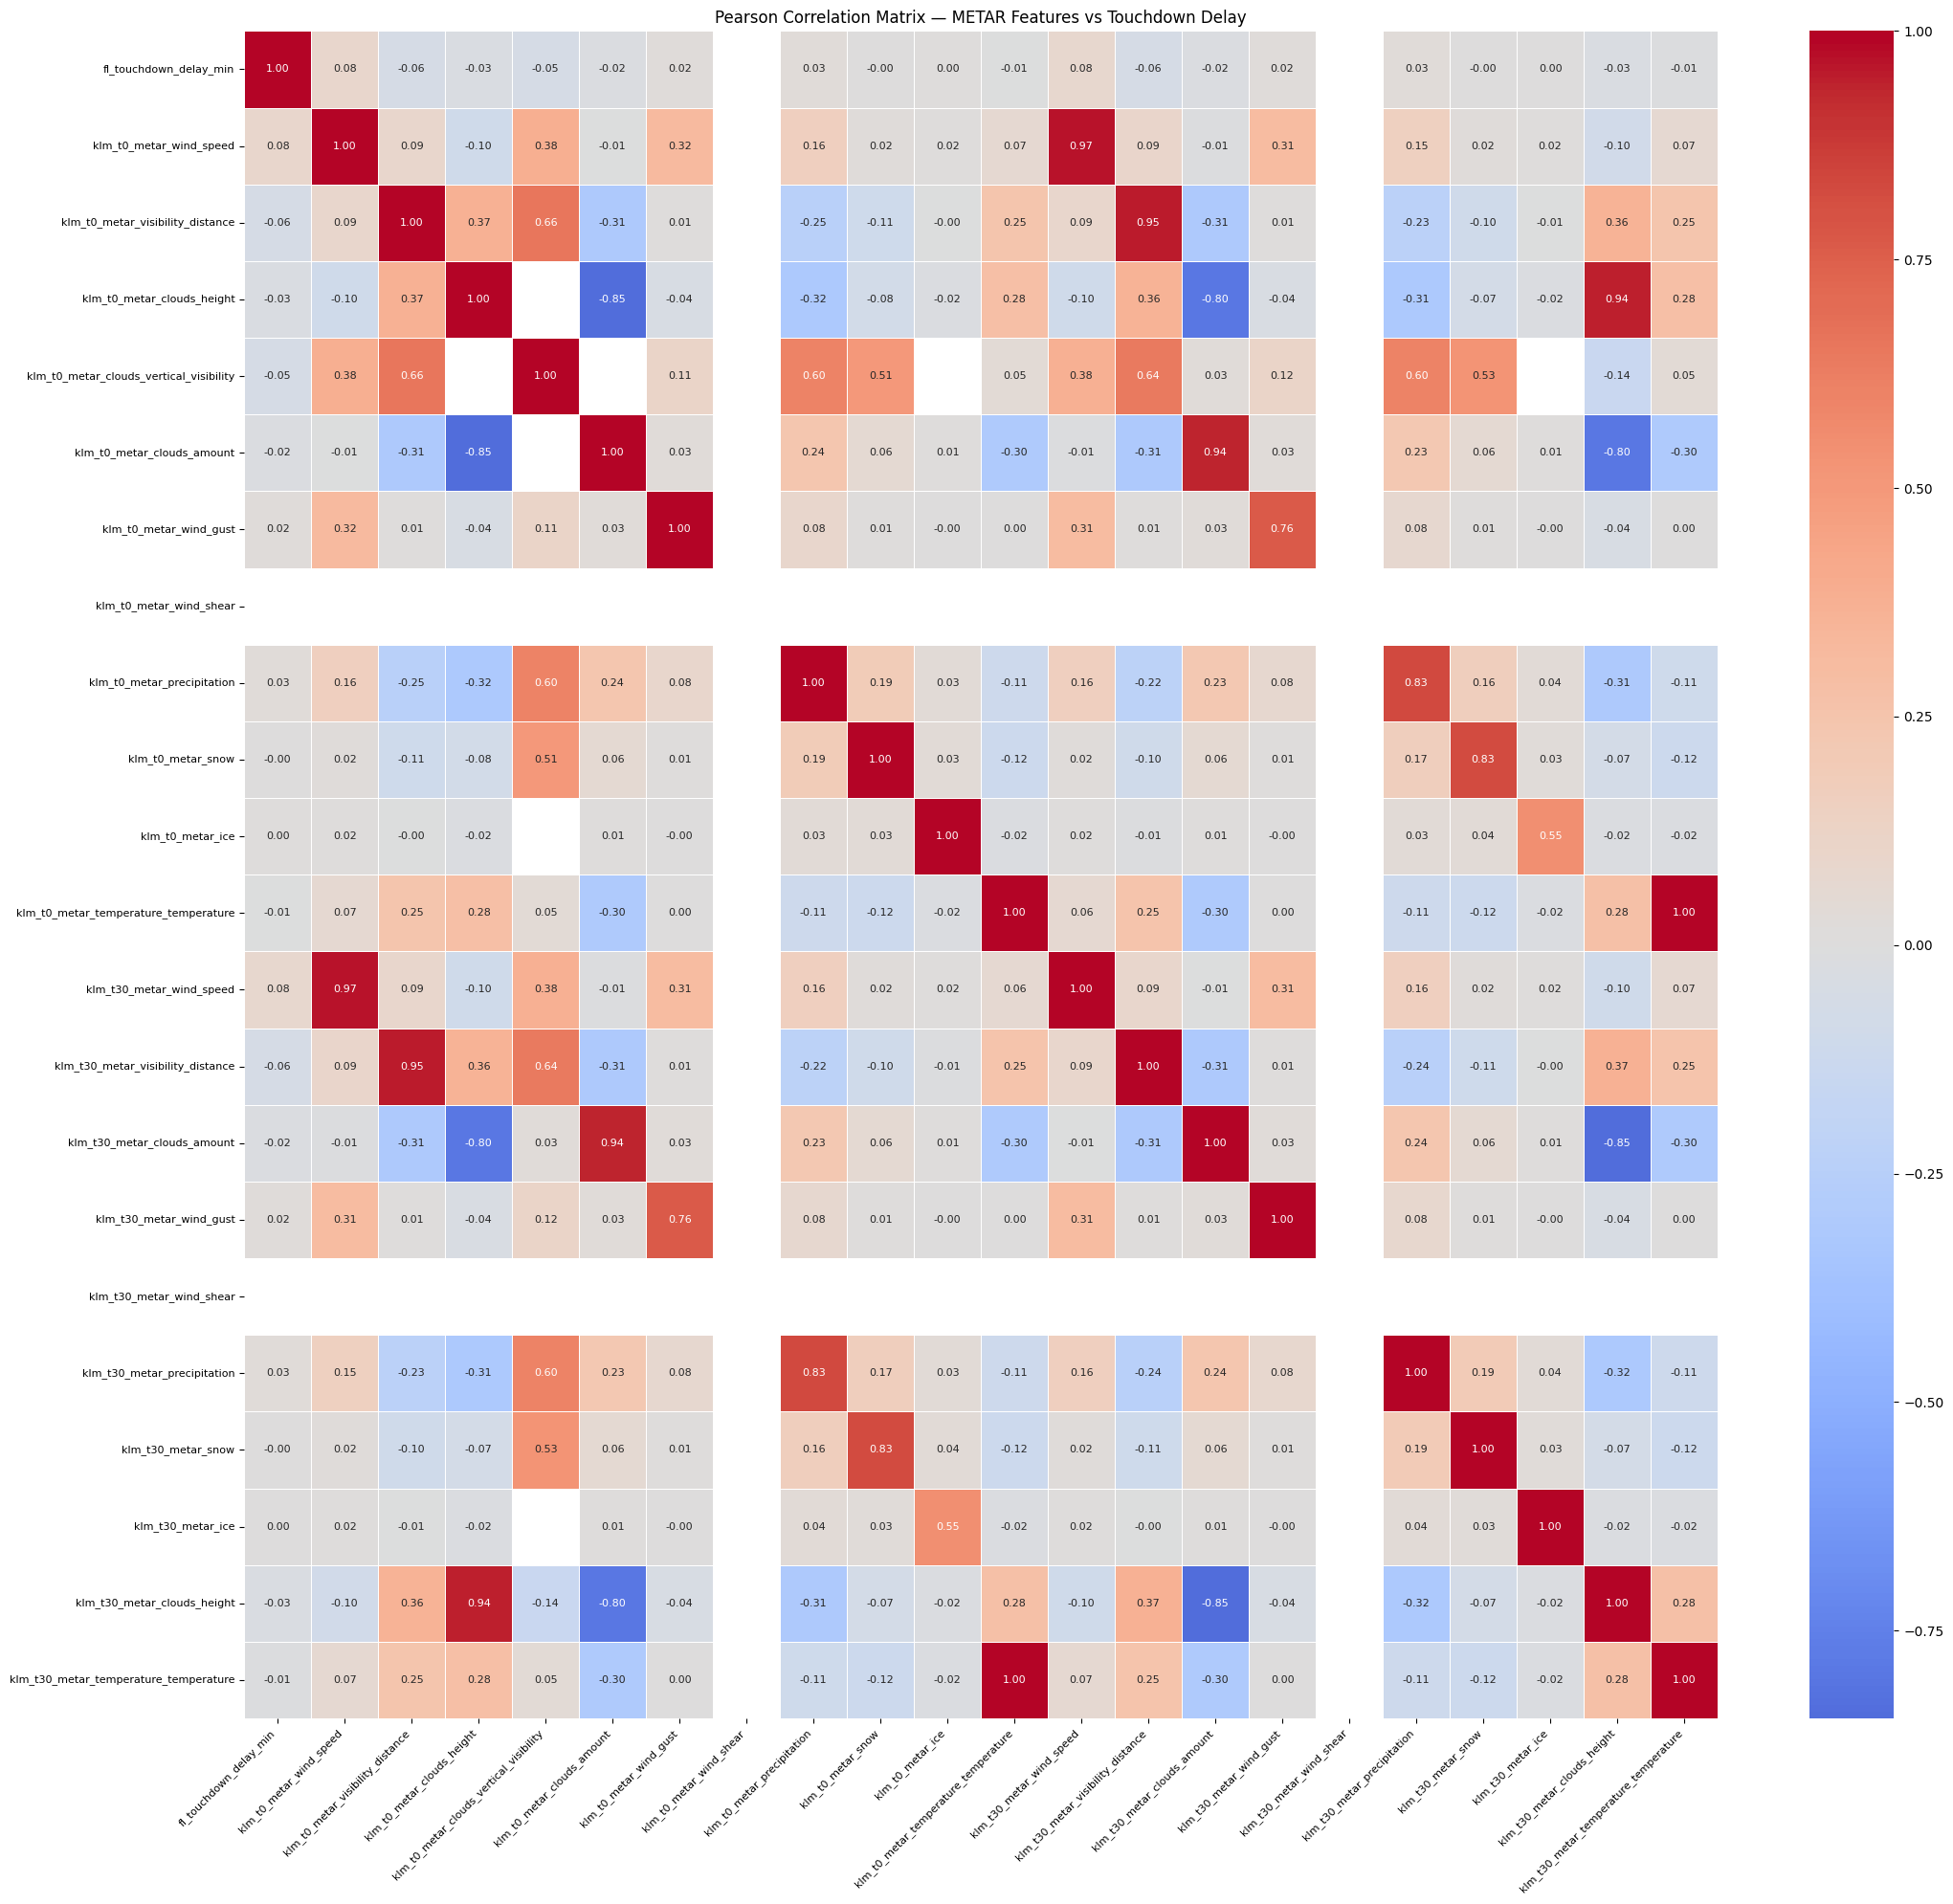

In [26]:
import pandas as pd

# Select the weather features and the target variable for correlation analysis
corr_cols = [
    "fl_touchdown_delay_min",
    "klm_t0_metar_wind_speed",
    "klm_t0_metar_visibility_distance",
    "klm_t0_metar_vertical_visibility_distance",
    "klm_t0_metar_clouds_height",
    "klm_t0_metar_clouds_vertical_visibility",
    "klm_t0_metar_clouds_amount",
    "klm_t0_metar_wind_gust",
    "klm_t0_metar_wind_shear",
    "klm_t0_metar_precipitation",
    "klm_t0_metar_snow",
    "klm_t0_metar_ice",
    "klm_t0_metar_temperature_temperature",
    "klm_t30_metar_wind_speed",
    "klm_t30_metar_visibility_distance",
    "klm_t30_metar_vertical_visibility_distance",
    "klm_t30_metar_clouds_amount",
    "klm_t30_metar_wind_gust",
    "klm_t30_metar_wind_shear",
    "klm_t30_metar_precipitation",
    "klm_t30_metar_snow",
    "klm_t30_metar_ice",
    "klm_t30_metar_clouds_height",
    "klm_t30_metar_temperature_temperature",
]
# Keep only columns that actually exist
corr_cols = [c for c in corr_cols if c in weather_features_df.columns]

corr_df = weather_features_df.select(corr_cols).to_pandas().astype(float)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(max(8, len(corr_cols)), max(6, len(corr_cols) - 2)))
import seaborn as sns
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Pearson Correlation Matrix — METAR Features vs Touchdown Delay")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

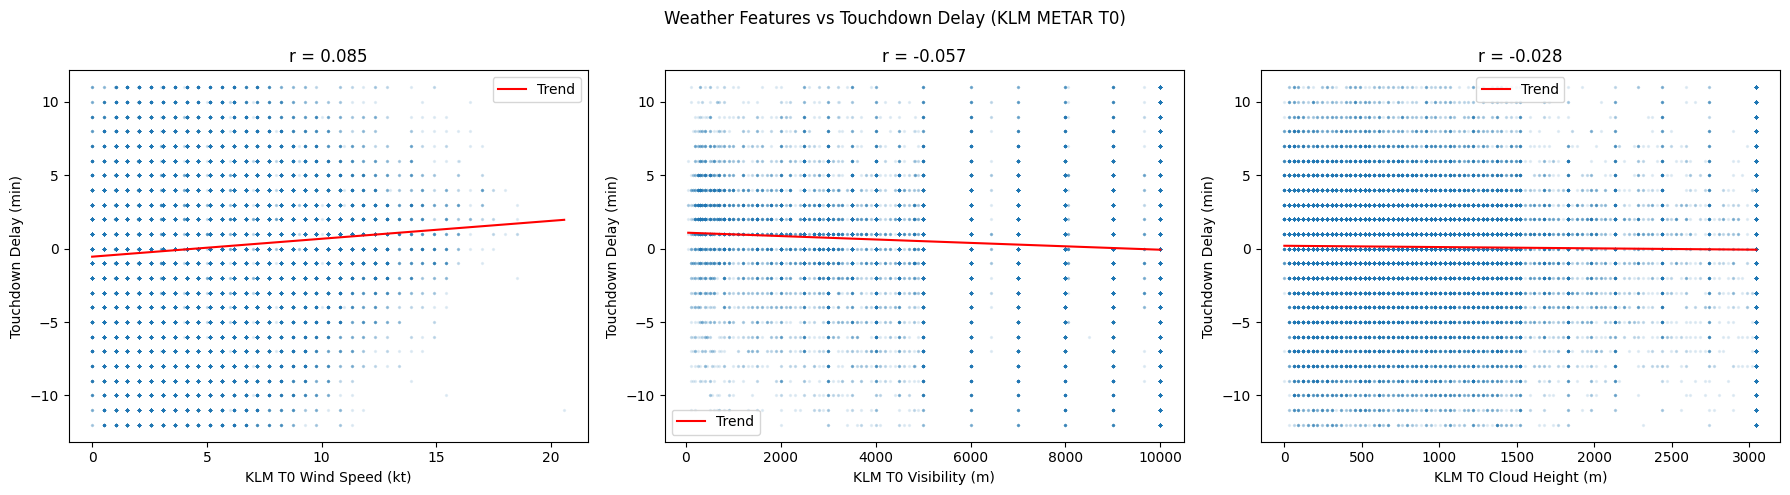

In [27]:
# Scatter plots: key weather features vs touchdown delay
scatter_features = [
    ("klm_t0_metar_wind_speed",          "KLM T0 Wind Speed (kt)"),
    ("klm_t0_metar_visibility_distance", "KLM T0 Visibility (m)"),
    ("klm_t0_metar_clouds_height",       "KLM T0 Cloud Height (m)"),
]
scatter_features = [(c, l) for c, l in scatter_features if c in weather_features_df.columns]

target_col = "fl_touchdown_delay_min"
if target_col in weather_features_df.columns and scatter_features:
    fig, axes = plt.subplots(1, len(scatter_features), figsize=(6 * len(scatter_features), 5))
    if len(scatter_features) == 1:
        axes = [axes]
    
    plot_pd = weather_features_df.select(
        [target_col] + [c for c, _ in scatter_features]
    ).to_pandas().dropna()
    
    for ax, (col, label) in zip(axes, scatter_features):
        ax.scatter(plot_pd[col], plot_pd[target_col], alpha=0.1, s=2, rasterized=True)
        # Trend line
        mask = plot_pd[col].notna() & plot_pd[target_col].notna()
        if mask.sum() > 10:
            z = np.polyfit(plot_pd.loc[mask, col], plot_pd.loc[mask, target_col], 1)
            p = np.poly1d(z)
            x_line = np.linspace(plot_pd[col].min(), plot_pd[col].max(), 100)
            ax.plot(x_line, p(x_line), color="red", linewidth=1.5, label="Trend")
        r = plot_pd[col].corr(plot_pd[target_col])
        ax.set_xlabel(label)
        ax.set_ylabel("Touchdown Delay (min)")
        ax.set_title(f"r = {r:.3f}")
        ax.legend()
    
    plt.suptitle("Weather Features vs Touchdown Delay (KLM METAR T0)", fontsize=12)
    plt.tight_layout()
    plt.show()


## Weather and Traffic Interactions

Combine weather severity with a traffic proxy (number of arrivals in the preceding 60-minute window) to assess whether congestion amplifies weather-related delays.


2026-05-15 12:13:30,437 - INFO - Pearson r (arrivals_60min vs fl_touchdown_delay_min): 0.230


ValueError: Bin edges must be unique: Index([0.0, 4.0, 4.0, 11.0, 21.0, 54.0], dtype='float64', name='arrivals_60min').
You can drop duplicate edges by setting the 'duplicates' kwarg

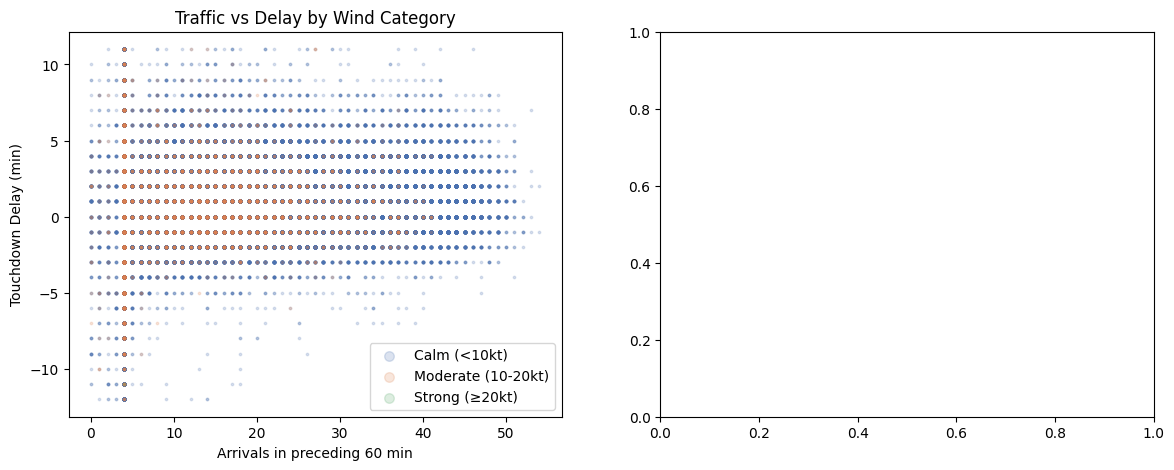

In [28]:
# Build a simple 60-min arrival traffic proxy using actual in-block times
if "fl_actual_in_block_time_utc" in weather_features_df.columns and "fl_touchdown_delay_min" in weather_features_df.columns:
    traffic_pd = weather_features_df.select([
        "flight_key_id",
        "fl_actual_in_block_time_utc",
        "lkpa_arrival_airport_icao_code",
        "fl_touchdown_delay_min",
        "klm_t0_metar_wind_speed",
        "klm_t0_metar_visibility_distance",
        "klm_t0_metar_clouds_height",
    ]).to_pandas()

    traffic_pd["fl_actual_in_block_time_utc"] = pd.to_datetime(traffic_pd["fl_actual_in_block_time_utc"])
    traffic_pd = traffic_pd.sort_values("fl_actual_in_block_time_utc")

    # Count arrivals per 15-min bin then rolling 60-min sum
    traffic_pd["arrival_bin"] = traffic_pd["fl_actual_in_block_time_utc"].dt.floor("15min")
    bin_counts = (
        traffic_pd.groupby(["lkpa_arrival_airport_icao_code", "arrival_bin"])
        .size()
        .rename("bin_count")
        .reset_index()
    )
    # Rolling sum within each airport (4 bins × 15 min = 60 min)
    bin_counts["arrivals_60min"] = (
        bin_counts.groupby("lkpa_arrival_airport_icao_code")["bin_count"]
        .transform(lambda s: s.rolling(4, min_periods=1).sum().shift(1).fillna(0))
    )
    traffic_pd = traffic_pd.merge(
        bin_counts[["lkpa_arrival_airport_icao_code", "arrival_bin", "arrivals_60min"]],
        on=["lkpa_arrival_airport_icao_code", "arrival_bin"],
        how="left",
    )

    # Correlation of traffic proxy with delay
    r_traffic = traffic_pd["arrivals_60min"].corr(traffic_pd["fl_touchdown_delay_min"])
    logging.info(f"Pearson r (arrivals_60min vs fl_touchdown_delay_min): {r_traffic:.3f}")

    # Categorise wind severity
    def wind_category(ws):
        if pd.isna(ws):
            return "Unknown"
        if ws < 10:
            return "Calm (<10kt)"
        if ws < 20:
            return "Moderate (10-20kt)"
        return "Strong (≥20kt)"

    traffic_pd["wind_cat"] = traffic_pd["klm_t0_metar_wind_speed"].apply(wind_category)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: traffic vs delay by wind category
    for cat, color in [("Calm (<10kt)", "#4C72B0"), ("Moderate (10-20kt)", "#DD8452"), ("Strong (≥20kt)", "#55A868")]:
        sub = traffic_pd[traffic_pd["wind_cat"] == cat].dropna(subset=["arrivals_60min", "fl_touchdown_delay_min"])
        axes[0].scatter(sub["arrivals_60min"], sub["fl_touchdown_delay_min"],
                        alpha=0.2, s=3, label=cat, color=color, rasterized=True)
    axes[0].set_xlabel("Arrivals in preceding 60 min")
    axes[0].set_ylabel("Touchdown Delay (min)")
    axes[0].set_title("Traffic vs Delay by Wind Category")
    axes[0].legend(markerscale=4)

    # Right: mean delay by wind category and traffic quintile
    traffic_pd["traffic_quintile"] = pd.qcut(
        traffic_pd["arrivals_60min"].fillna(0), 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )
    pivot = (
        traffic_pd.dropna(subset=["fl_touchdown_delay_min"])
        .groupby(["wind_cat", "traffic_quintile"])["fl_touchdown_delay_min"]
        .mean()
        .unstack("traffic_quintile")
    )
    pivot.T.plot(kind="bar", ax=axes[1], alpha=0.8)
    axes[1].set_xlabel("Traffic Quintile (Q1=least busy, Q5=busiest)")
    axes[1].set_ylabel("Mean Touchdown Delay (min)")
    axes[1].set_title("Mean Delay by Wind Severity × Traffic Quintile")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="Wind Category", fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    logging.warning("Traffic proxy analysis skipped: required columns not found.")